# Streamflow Intermittence In Transient


In [2]:
# -*- coding: utf-8 -*-
"""
 * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy
 *
 * This program and the accompanying materials are made available under the
 * terms of the Eclipse Public License 2.0 which is available at
 * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0
 * which is available at https://www.apache.org/licenses/LICENSE-2.0.
 *
 * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0
"""



'\n * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy\n *\n * This program and the accompanying materials are made available under the\n * terms of the Eclipse Public License 2.0 which is available at\n * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0\n * which is available at https://www.apache.org/licenses/LICENSE-2.0.\n *\n * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0\n'

In [3]:
# Libraries installed by default
import sys
import glob

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False
import xarray as xr
xr.set_options(keep_attrs = True)

# ROOT DIRECTORY
from os.path import dirname, abspath
try:
    root_dir = '/home/bb/Documents/01_Git_Repository/01-HydroModPy-dev'
except NameError:
    root_dir = os.getcwd()
sys.path.append(root_dir)

# HYDROMODPY MODULES
from hydromodpy import watershed_root
from hydromodpy.display import visualization_watershed, visualization_results
from hydromodpy.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20)  # small, medium, interm, large

def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df



In [4]:

example_path = os.path.join(root_dir, "examples", "04_streamflow_intermittence_in_transient/")
data_path = os.path.join(example_path, "data/")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(root_dir,'examples', 'results')
# Or define it manually
# out_path = 'C:/Simulations/HydroModPy/'

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results


In [5]:

dem_path = os.path.join(data_path, 'regional dem.tif')
load = True
watershed_name = 'Example_04_Nancon'
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = None # [path, buffer size]
from_xyv = [389285.910, 6816518.749, 150, 10 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
bottom_path = None # path
save_object = True



In [6]:

print('##### '+watershed_name.upper()+' #####')

BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = os.path.join(out_path, watershed_name, 'results_stable')
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')



[INFO]       __  __          __           __  ____          ________     


[INFO]      / / / /         / /          /  \/   /         / / __  /     


[INFO]     / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 


[INFO]    / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 


[INFO]   / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  


[INFO]  /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   


[INFO]        /____/ Hydrological Modelling in Python /_____________/    


[INFO]                                                                   


[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_04_Nancon


##### EXAMPLE_04_NANCON #####


[INFO] Extracting geology data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/04_streamflow_intermittence_in_transient/data/


[INFO] Extracting hydrography data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/04_streamflow_intermittence_in_transient/data/


[INFO] Extracting hydrometry data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/04_streamflow_intermittence_in_transient/data/


[INFO] Extracting stream intermittency data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/04_streamflow_intermittence_in_transient/data/


[INFO] Extracting subbasin definitions for watershed


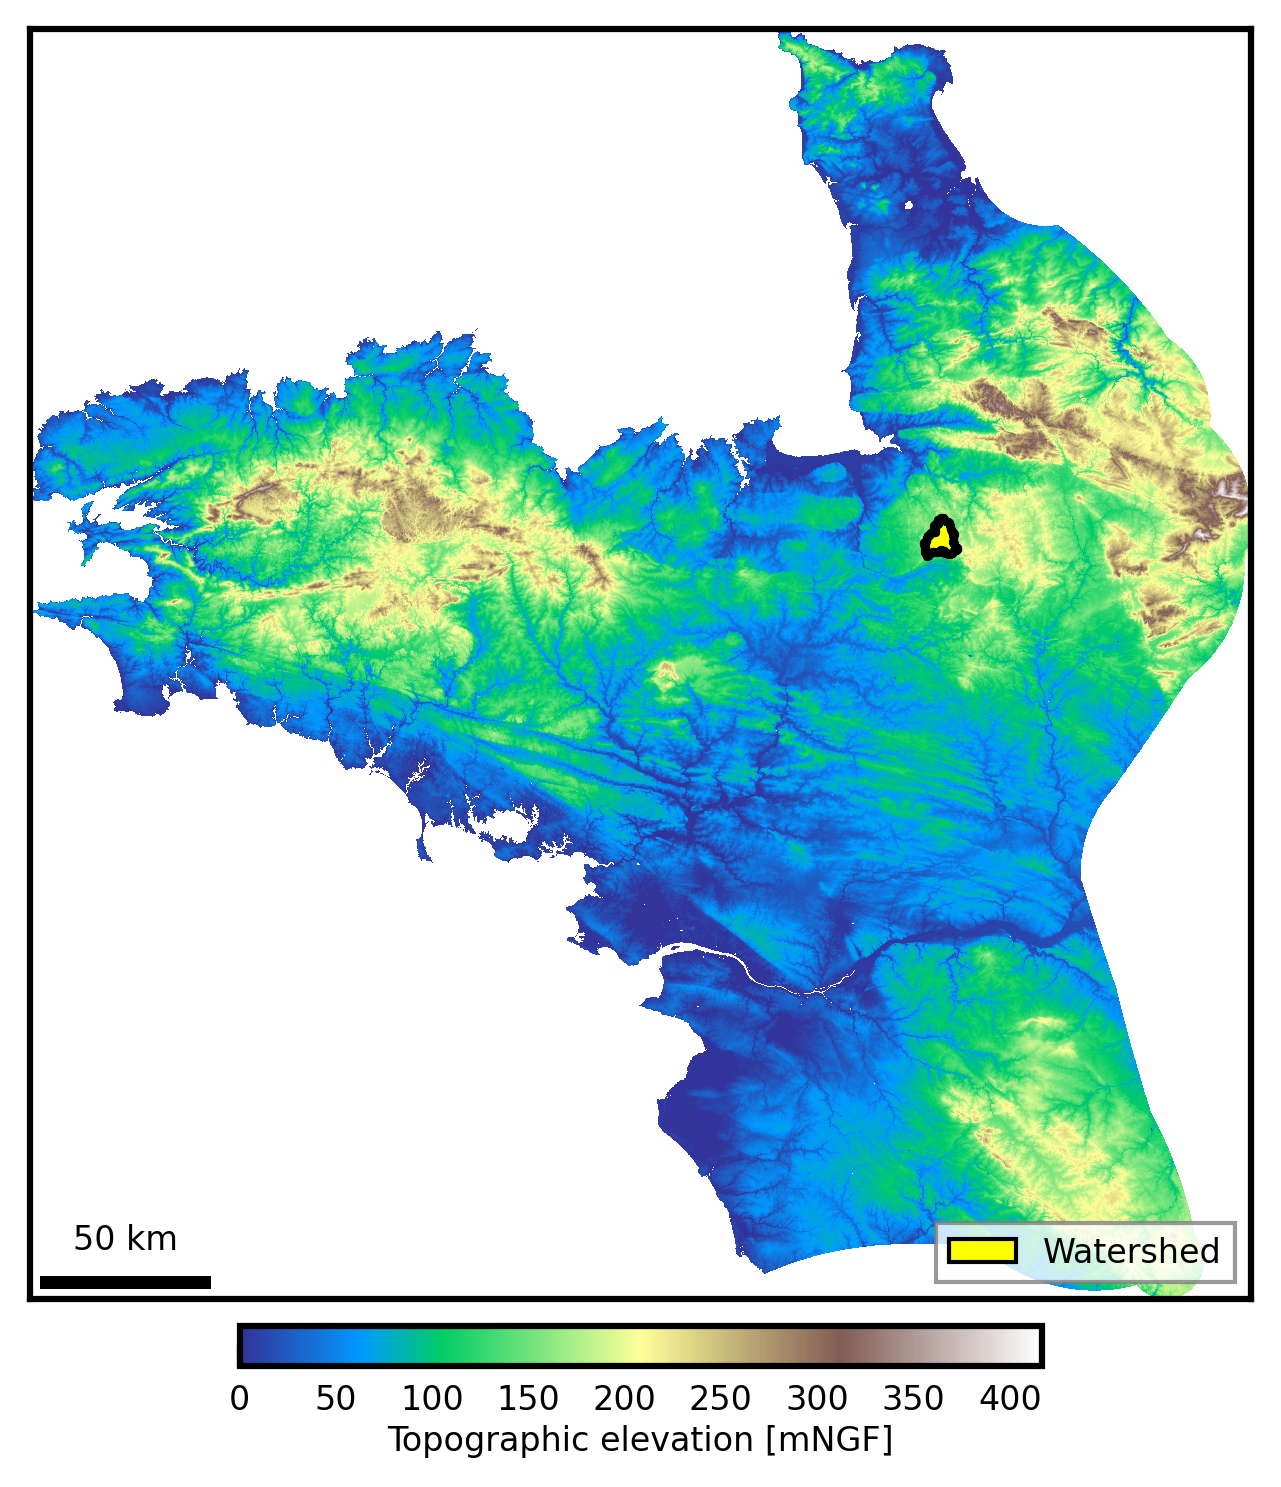

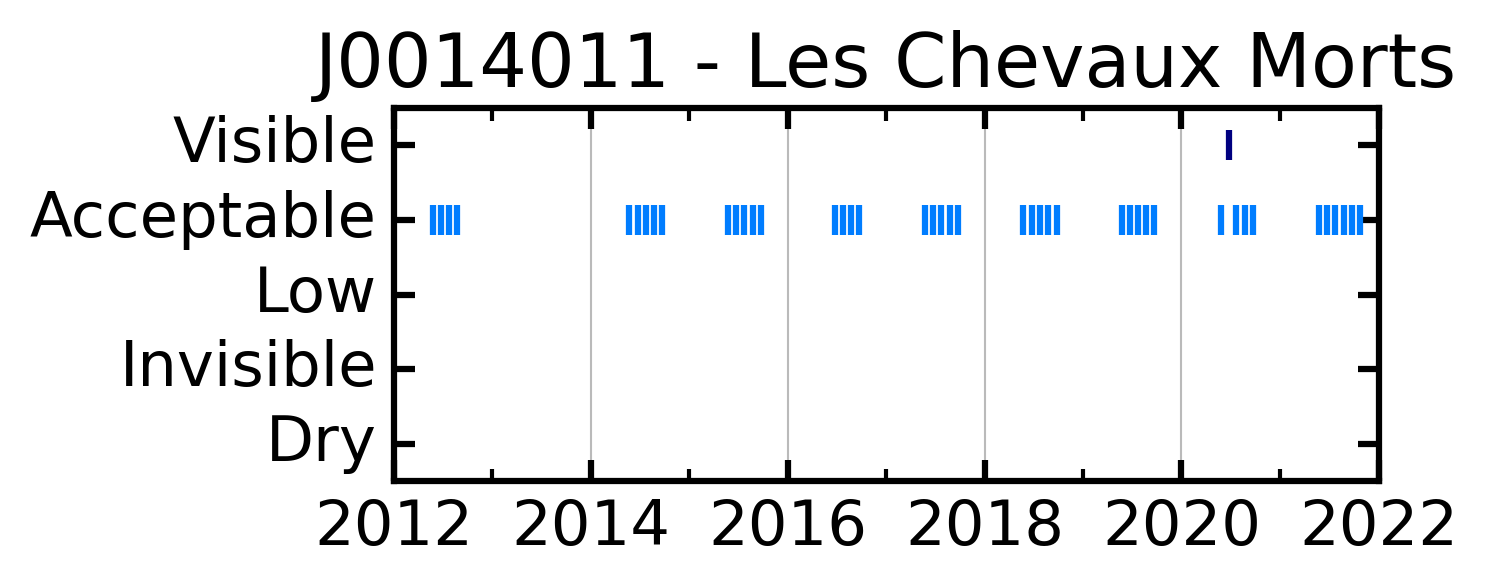

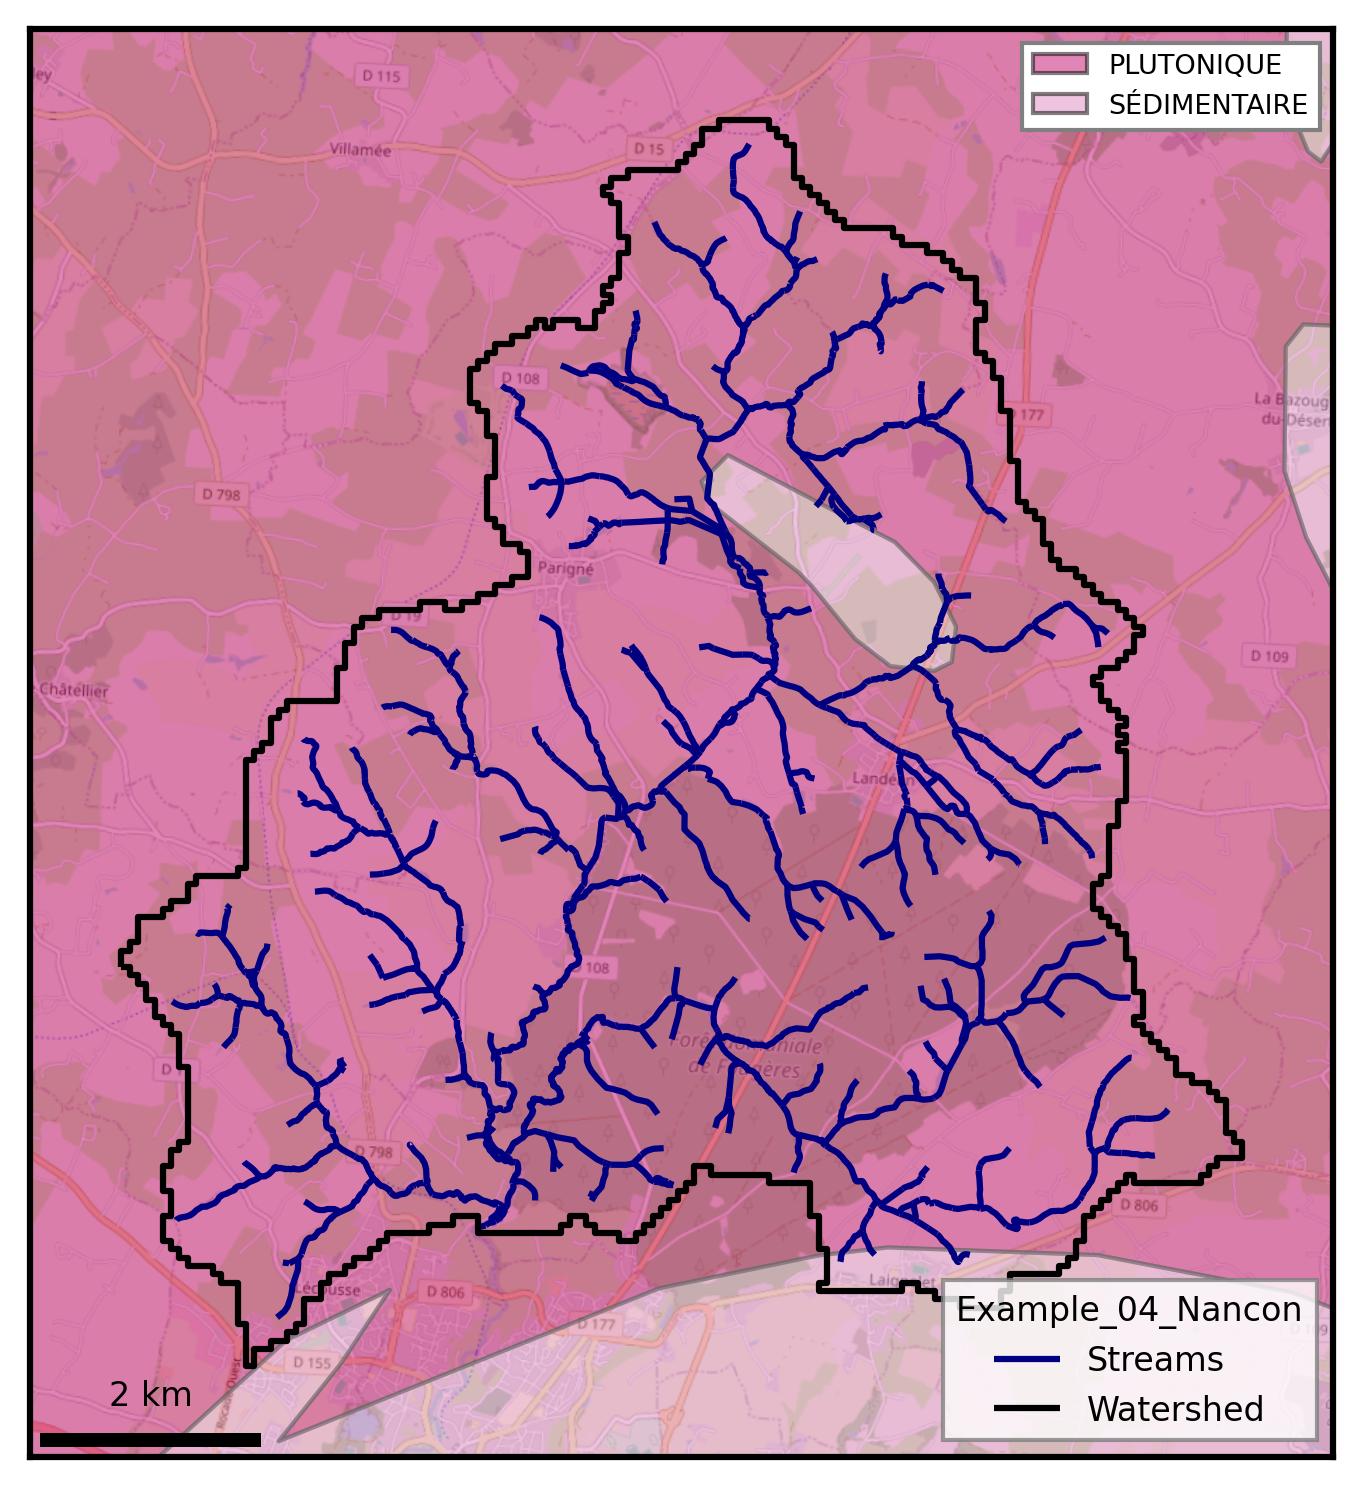

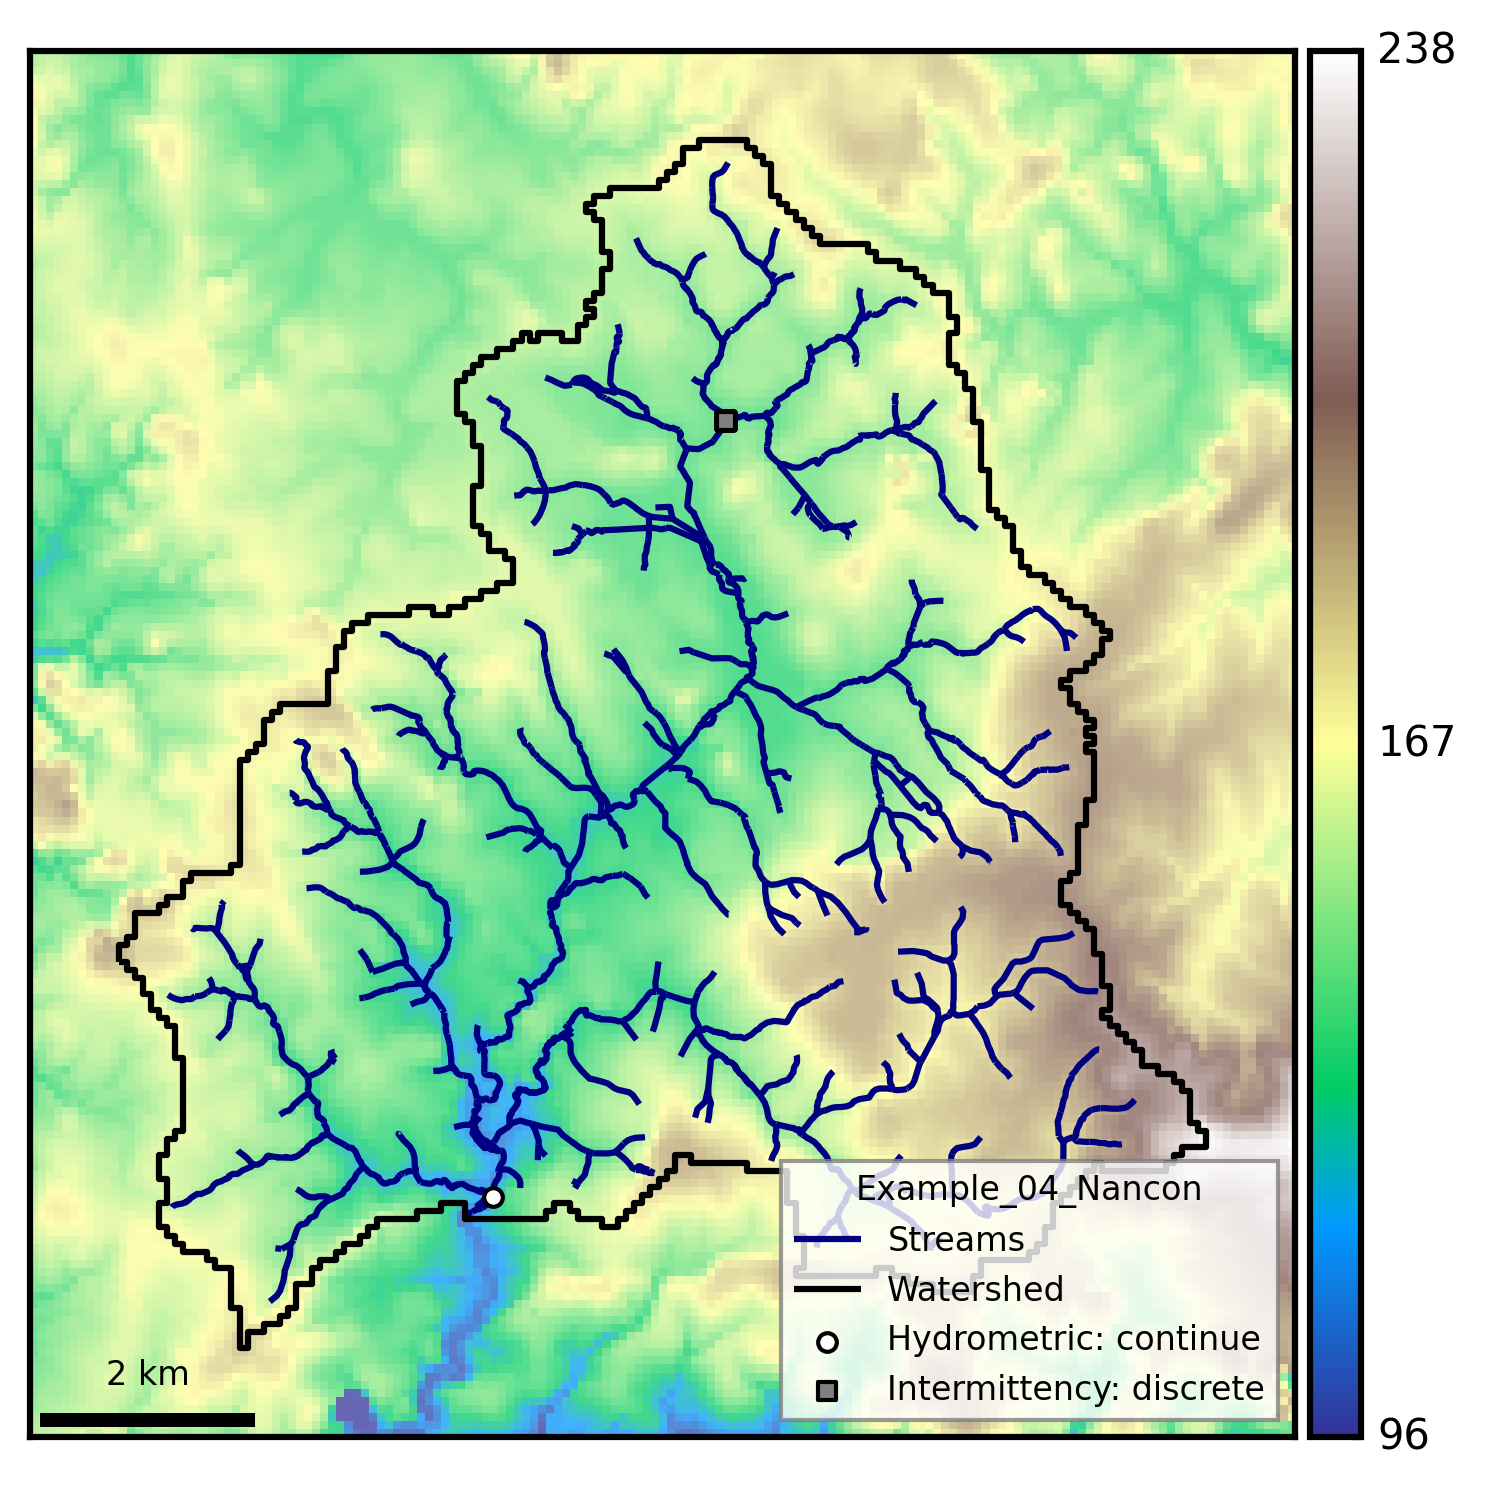

In [7]:

visualization_watershed.watershed_local(dem_path, BV)

# Clip specific data at the catchment scale
BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
BV.add_hydrography(data_path, types_obs=['regional stream network'])
BV.add_hydrometry(data_path, 'france hydrometric stations.shp')
BV.add_intermittency(data_path, 'regional onde stations.shp')
# BV.add_piezometry()

# Extract some subbasin from data available above
BV.add_subbasin(os.path.join(data_path, 'additional'), 150)

# General plot of the study site
visualization_watershed.watershed_geology(BV)
visualization_watershed.watershed_dem(BV)



[INFO] Initializing climatic module parameters


[INFO] Extracting SIM2 climatic datasets from remote archives


[INFO] Existing SIM2 CSV datasets already cover requested domain and period


[INFO] Clipping NetCDF files with mask watershed_box


[INFO] Merging DRAINC (recharge) NetCDF files


[INFO] Merging RUNC (runoff) NetCDF files


[INFO] Formatting SIM2 results for HydroModPy


[INFO] Processing SIM2 variable recharge


[INFO] Processing SIM2 variable runoff


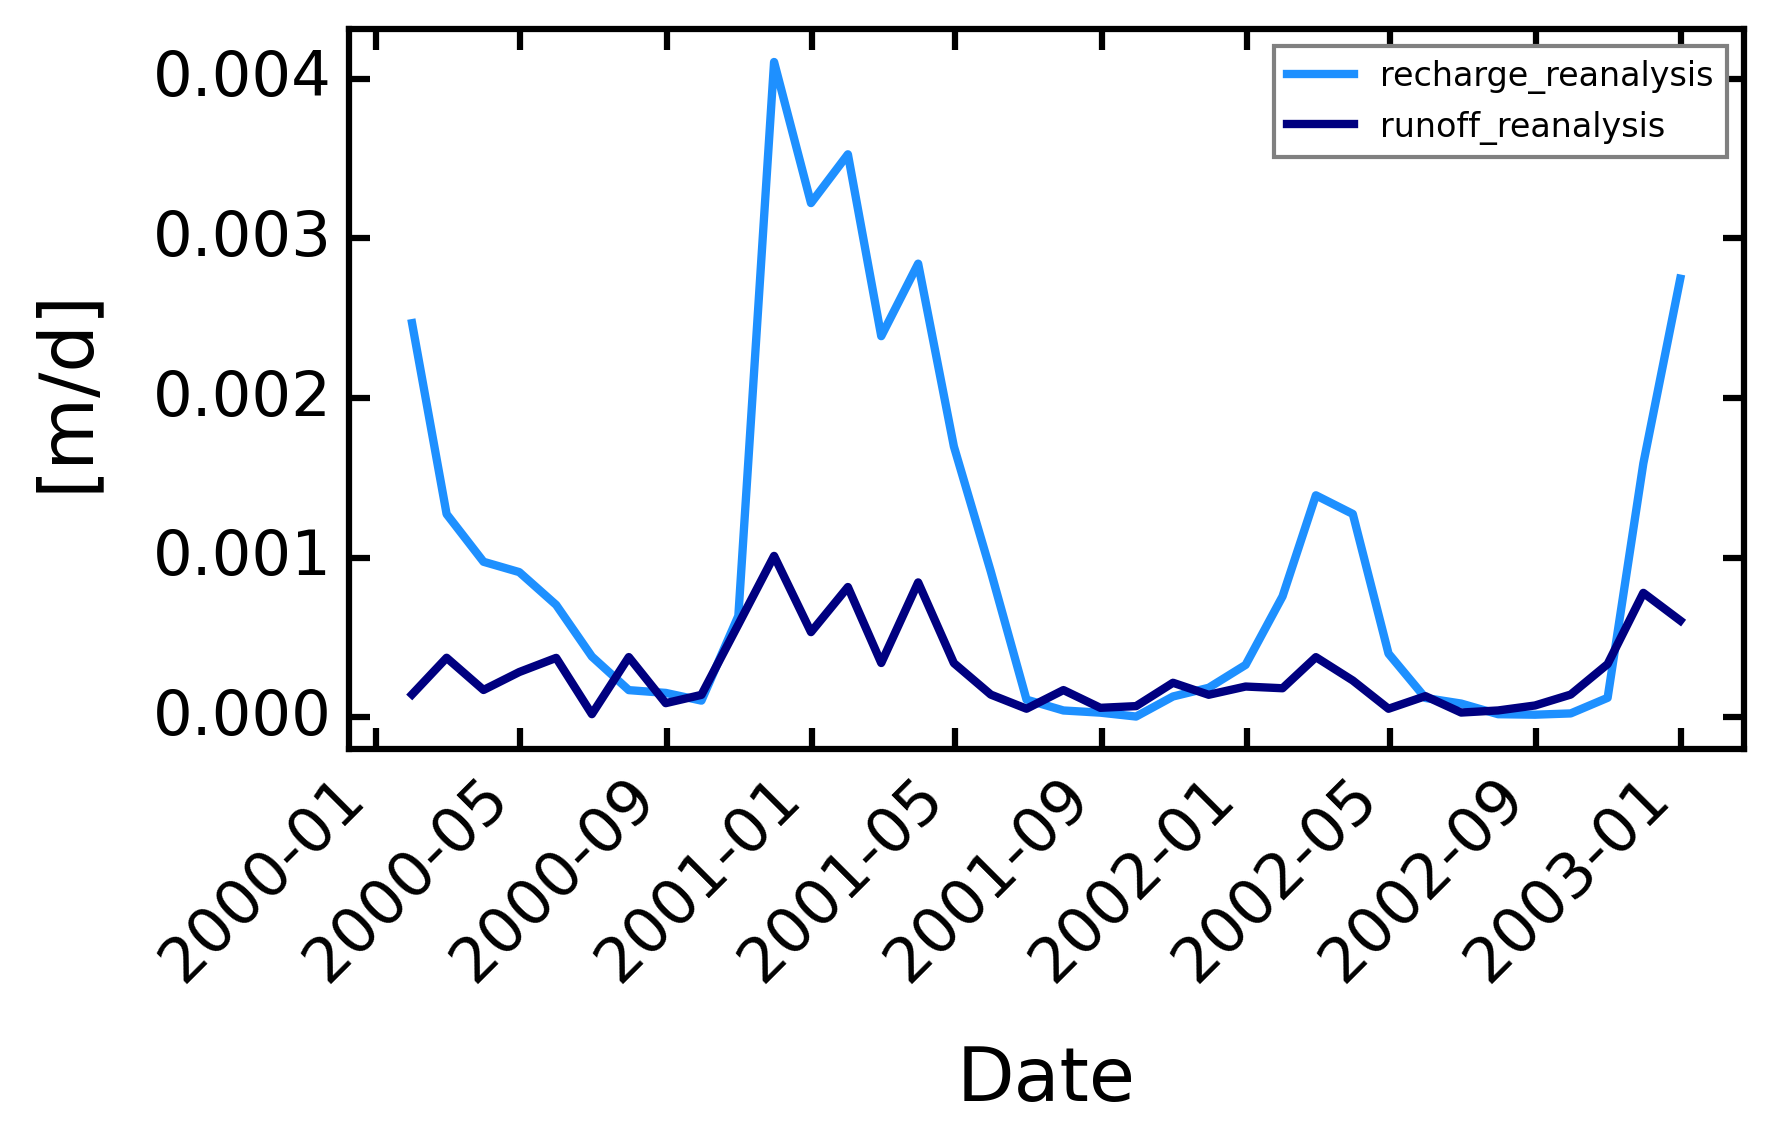

In [ ]:

# Necessary to set model parameters
BV.add_climatic()

# clim_data_mode = 'local' # local climatic data
clim_data_mode = 'SIM2' # SIM2 online climatic data (https://meteo.data.gouv.fr/datasets/6569b27598256cc583c917a7)

if clim_data_mode == 'SIM2':
    BV.climatic.update_sim2_reanalysis(var_list=['recharge', 'runoff',
                                                ],
                                            nc_data_path=os.path.join(
                                                stable_folder,
                                                'add_data',
                                                'climatic'),
                                            first_year=2000,
                                            last_year=2002,
                                            time_step='M',
                                            sim_state='transient',
                                            spatial_mean=True,
                                            geographic=BV.geographic,
                                            disk_clip='watershed')

    ### Units
    BV.climatic.update_recharge(BV.climatic.recharge / 1000, sim_state='transient') # from mm to m
    BV.climatic.update_runoff(BV.climatic.runoff / 1000, sim_state='transient') # from mm to m

    ### Format for plots
    if isinstance(BV.climatic.recharge, float):
        print(f"Time-space daily average value for recharge = {BV.climatic.recharge} m")
        print(f"Time-space daily average value for runoff = {BV.climatic.runoff} m")
    else:
        if isinstance(BV.climatic.recharge, xr.core.dataset.Dataset):
            R = BV.climatic.recharge.drop('spatial_ref').mean(dim = ['x', 'y']).to_pandas().iloc[:,0]
            r = BV.climatic.runoff.drop('spatial_ref').mean(dim = ['x', 'y']).to_pandas().iloc[:,0]
            # R = R.resample('M').sum()
            # r = r.resample('M').sum()
        elif isinstance(BV.climatic.recharge, pd.core.series.Series):
            R = BV.climatic.recharge
            r = BV.climatic.runoff

elif clim_data_mode == 'local':
    x = pd.read_csv(data_path+'/'+'_climate_REANALYSIS.csv', sep=';', index_col=0)
    date_object = pd.to_datetime(x.index, format = "%d/%m/%Y")
    x.index = date_object
    x = x.sort_index()
    x = x.resample('M').mean()
    x = select_period(x, 2000, 2002)
    BV.climatic.update_recharge(x['REC_REA_historic'] / 1000, sim_state='transient') # from mm to m
    BV.climatic.update_runoff(x['RUN_REA_historic'] / 1000, sim_state='transient') # from mm to m
    R = BV.climatic.recharge
    r = BV.climatic.runoff

# Plots
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[m/d]')
plt.xticks(rotation=45, ha="right")
ax.legend()



In [9]:

# Frame settings
box = True # or False
sink_fill = False # or True
# sim_state = 'transient' # 'steady' or 'transient'
sim_state = 'transient' # 'steady' or 'transient'
plot_cross = False
dis_perlen = True

# Climatic settings
first_clim = 'first' # or 'first or value
freq_time = 'M'

# Hydraulic settings
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 30 # if bottom is None, aquifer thickness
hk = 5e-5 * 3600 * 24 # m/day
cond_drain = None # or value of conductance

########## LOOP ##########
list_porosity = np.array([0.1, 5, 30]) / 100 # [-]

# Boundary settings
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL
split_temp = True

# Particle tracking settings
zone_partic = 'domain' # or watershed

# plt.plot(hyd_cond/R)

iD_set_simulations = 'explorSy_test1'



In [10]:

# Import modules
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()

# Frame settings
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_check_model(plot_cross=plot_cross)

# Climatic settings
recharge = R.copy()
BV.climatic.update_recharge(recharge, sim_state=sim_state)
BV.climatic.update_first_clim(first_clim)

# Hydraulic settings
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None
BV.hydraulic.update_hk(hk)
BV.hydraulic.update_cond_drain(cond_drain)

# Boundary settings
BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)
BV.settings.update_dis_perlen(dis_perlen)

# Particle tracking settings
BV.settings.update_input_particles(zone_partic=BV.geographic.watershed_box_buff_dem) # or 'seepage_path'



[INFO] Initializing settings module for groundwater parameters


[INFO] Initializing climatic module parameters


[INFO] Initializing hydraulic module for parameter setup


In [ ]:

list_model_name = []
list_success_modflow = []
list_model_modflow = []

for i, sy in enumerate(list_porosity[:]):
    BV.hydraulic.update_sy(sy)

    model_name = iD_set_simulations+'_'+str(i)+'_'+str(round(sy,3))
    BV.settings.update_model_name(model_name)
    print(model_name)

    model_modflow = BV.preprocessing_modflow(for_calib=False)
    success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)

    list_model_name.append(model_name)
    list_success_modflow.append(success_modflow)
    list_model_modflow.append(model_modflow)

dictio = {}
dictio['list_model_name'] = list_model_name
dictio['list_success_modflow'] = list_success_modflow
dictio['list_model_modflow'] = list_model_modflow
pickle_file = os.path.join(simulations_folder, 'results_listing_'+iD_set_simulations+'.pkl')

with open(pickle_file, 'wb') as f:
    pickle.dump(dictio, f)



[INFO] MODFLOW grid connectivity check passed


explorSy_test1_0_0.001


FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorSy_test1_0_0.001.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:45:03

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.


 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.


...

 Solving:  Stress period:    28    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    29    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    30    Time step:     1    Groundwater-Flow Eqn.


 Solving:  Stress period:    31    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    32    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    33    Time step:     1    Groundwater-Flow Eqn.


 Solving:  Stress period:    34    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    35    Time step:     1    Groundwater-Flow Eqn.


 Solving:  Stress period:    36    Time step:     1    Groundwater-Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:46:14
 Elapsed run time:  4.617 Seconds



  Normal termination of simulation


In [12]:

iD_set_simulations = 'explorSy_test1'

pickle_file = os.path.join(simulations_folder, 'results_listing_'+iD_set_simulations+'.pkl')
with open(pickle_file, 'rb') as f:
    d = pickle.load(f)
list_model_name = d['list_model_name'][:]
list_success_modflow = d['list_success_modflow'][:]
list_model_modflow = d['list_model_modflow'][:]



In [ ]:

# from importlib import reload
# reload(watershed_root)
# reload(modflow)

for model_name, success_modflow, model_modflow in zip(list_model_name,
                                                      list_success_modflow,
                                                      list_model_modflow):
    if success_modflow == True:
        BV.postprocessing_modflow(model_modflow,
                                  watertable_elevation = True,
                                  watertable_depth= True,
                                  seepage_areas = True,
                                  outflow_drain = True,
                                  groundwater_flux = True,
                                  groundwater_storage = True,
                                  accumulation_flux = True,
                                  persistency_index=True,
                                  intermittency_monthly=True,
                                  intermittency_daily=False,
                                  export_all_tif = False)

        timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                          model_modpath=None,
                                                          datetime_format=True,
                                                          subbasin_results=True,
                                                          intermittency_monthly=True) # or None

        netcdf_results = BV.postprocessing_netcdf(model_modflow,
                                                  datetime_format=True)



[INFO] Post-processing stress period 1/36


[INFO] Post-processing stress period 2/36


[INFO] Post-processing stress period 3/36


[INFO] Post-processing stress period 4/36


[INFO] Post-processing stress period 5/36


...

[INFO] Exported catchment time series to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_04_Nancon/results_simulations/explorSy_test1_2_0.3/_postprocess/_timeseries


[INFO] Exported time series for subbasin 1 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_04_Nancon/results_simulations/explorSy_test1_2_0.3/_subbasins/hydrometry_J0014010


[INFO] Exported time series for subbasin 2 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_04_Nancon/results_simulations/explorSy_test1_2_0.3/_subbasins/subbasin_upstreamA


[INFO] Exported time series for subbasin 3 to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_04_Nancon/results_simulations/explorSy_test1_2_0.3/_subbasins/intermittency_J0014011


[INFO] Exporting MODFLOW results as NetCDF for model explorSy_test1_2_0.3


32
2002-09
10
2000-11
33
2002-10
0
2000-01
33
2002-10
0
2000-01


<bound method Figure.tight_layout of <Figure size 1500x3000 with 3 Axes>>

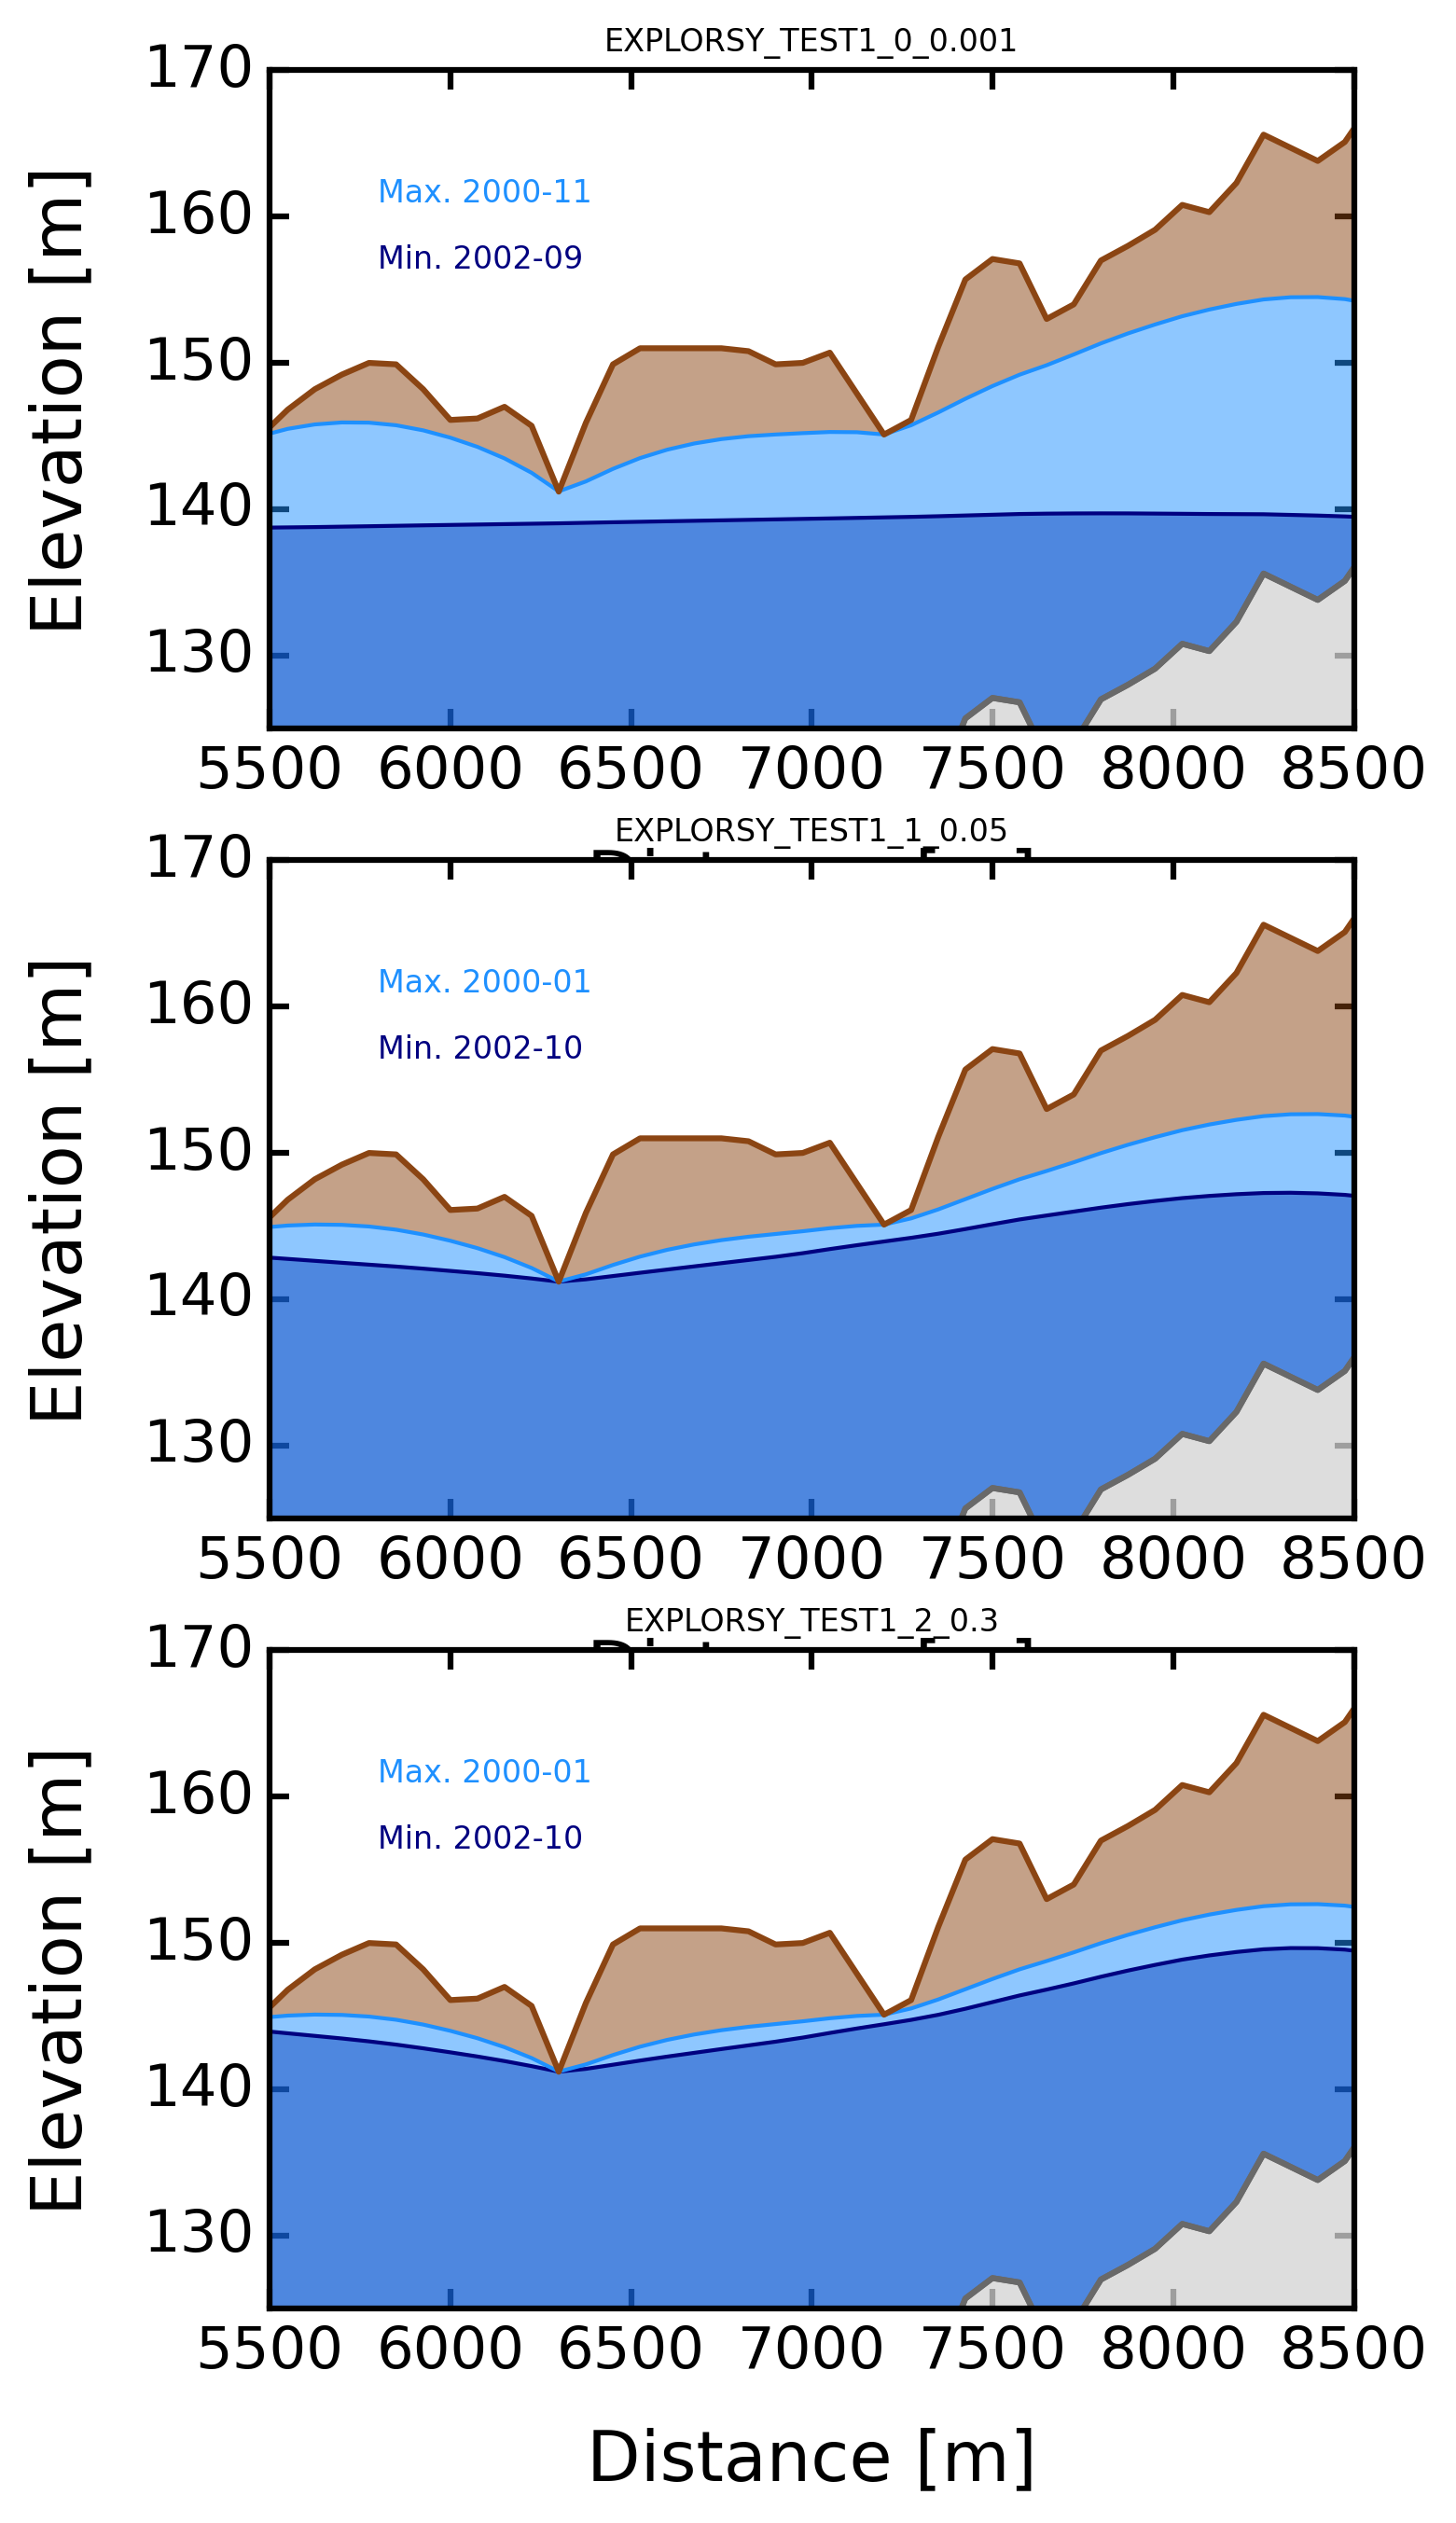

In [ ]:

dates = pd.date_range(start='01/01/2000', end='31/12/2002', freq='M')

stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

simul_list = sorted(glob.glob(os.path.join(simulations_folder, iD_set_simulations+'*')),
                    key=os.path.getmtime)

fig, axs = plt.subplots(3, 1, figsize=(5,10), dpi=300)
axs = axs.ravel()

for i, simul in enumerate(simul_list[:]):

    model_name = os.path.split(simul)[-1]

    ax = axs[i]

    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)
    Smod = Smod.reset_index()
    argmin = Smod['total_areas'].argmin()
    argmax = Smod['total_areas'].argmax()

    mask = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_dem.tif'))


    watertable_elevation = np.load(os.path.join(simulations_folder,
                                                model_name, '_postprocess',
                                                'watertable_elevation'+'.npy'),
                                   allow_pickle=True).item()

    min_wt = dict()

    cp = 0

    for i, key in enumerate([argmin, argmax]):
        print(key)

        dem_data = imageio.imread(BV.geographic.watershed_dem)
        wt_data = watertable_elevation[key]
        # river_data = imageio.imread(os.path.join(stable_folder, 'hydrography',
        #                                           'regional stream network.tif'))

        xvalues = np.linspace(-1,1,dem_data.shape[1])
        yvalues = np.linspace(-1,1,dem_data.shape[0])
        xx, yy = np.meshgrid(xvalues,yvalues)

        cur_x = dem_data.shape[1] /2
        cur_y = dem_data.shape[0] /2 # 39
        cur_y = 39

        dem_max = dem_data.max()
        dem_prof = dem_data.astype(float)
        dem_prof[dem_prof<0] = np.nan
        wt_prof = wt_data.astype(float)
        wt_prof[wt_prof<0] = np.nan

        dem_h_plot = dem_prof[int(cur_y),:]
        dem_h_plot[dem_h_plot == 0] = np.nan
        wt_h_plot = wt_prof[int(cur_y),:]
        wt_h_plot[wt_h_plot == 0] = np.nan

        dem_max = dem_data.max()
        dem_prof = dem_data.astype(float)
        dem_prof[dem_prof<0] = np.nan
        dem_plot = np.ma.masked_array(dem_data, mask=(dem_data<0))

        wt_prof = wt_data.astype(float)
        wt_prof[wt_prof<0] = np.nan

        cp+=1

        if i == 0:
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, dem_h_plot-30, wt_h_plot,
                                            color='navy', alpha=0.5, lw=0)
            w_prof = ax.plot(np.arange(xx.shape[1])*75, wt_h_plot, color='navy', lw=1)
        if i == 1:
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, dem_h_plot-30, wt_h_plot,
                                            color='dodgerblue', alpha=0.5, lw=0)
            w_prof = ax.plot(np.arange(xx.shape[1])*75, wt_h_plot, color='dodgerblue', lw=1)
            wt_h_fill = ax.fill_between(np.arange(xx.shape[1])*75, wt_h_plot, dem_h_plot,
                                            color='saddlebrown', alpha=0.5, lw=0)
            d_prof = ax.plot(np.arange(xx.shape[1])*75, dem_h_plot, 'saddlebrown', lw=1.5)
        ax.fill_between(np.arange(xx.shape[1])*75, 0, dem_h_plot-30,
                                        color='lightgrey', alpha=0.5, lw=0)
        ax.plot(np.arange(xx.shape[1])*75, dem_h_plot-30, color='dimgray', lw=1.5)
        ax.set_xlim(5500, 8500)
        ax.set_ylim(125, 170)
        ax.set_yticks([130,140,150,160,170])
        ax.set_xlabel('Distance [m]')
        ax.set_ylabel('Elevation [m]')

        ax.set_title(model_name.upper(), fontsize=8)
        if i == 1:
            ax.text(0.1, 0.8, 'Max. '+str(dates[key])[:7],
                    transform=ax.transAxes, color='dodgerblue')
        if i == 0:
            ax.text(0.1, 0.7, 'Min. '+str(dates[key])[:7],
                    transform=ax.transAxes, color='navy')
        print((str(dates[key])[:7]))

fig.tight_layout

# fig.savefig(os.path.join(simulations_folder, '_figures',
#             'CROSS_'+iD_set_simulations+'.png'),
#             bbox_inches='tight')



0/3
1/3
2/3


0/3
1/3
2/3


0/3
1/3
2/3


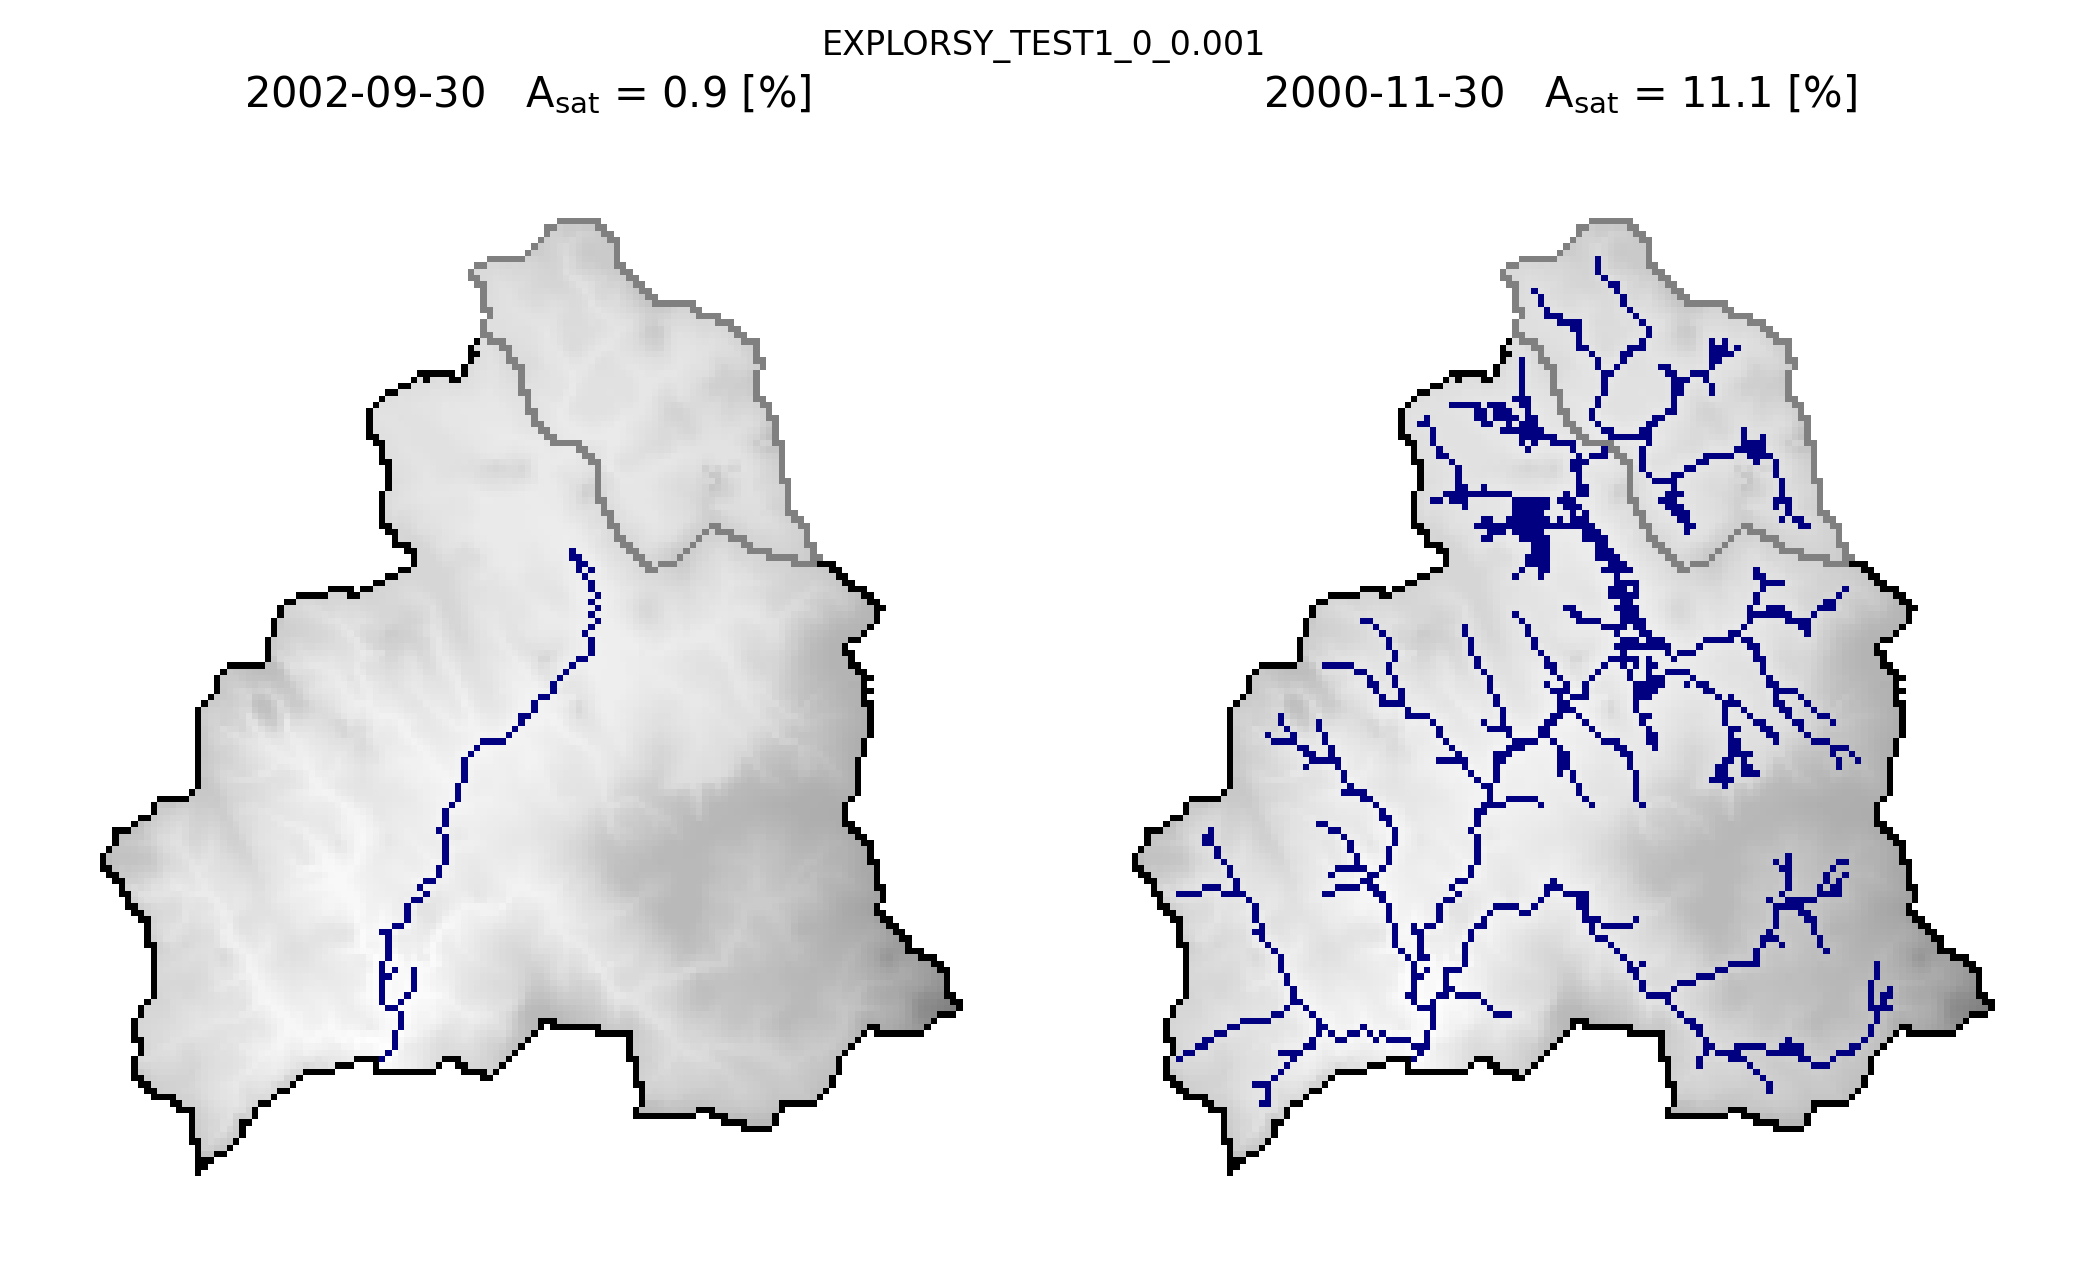

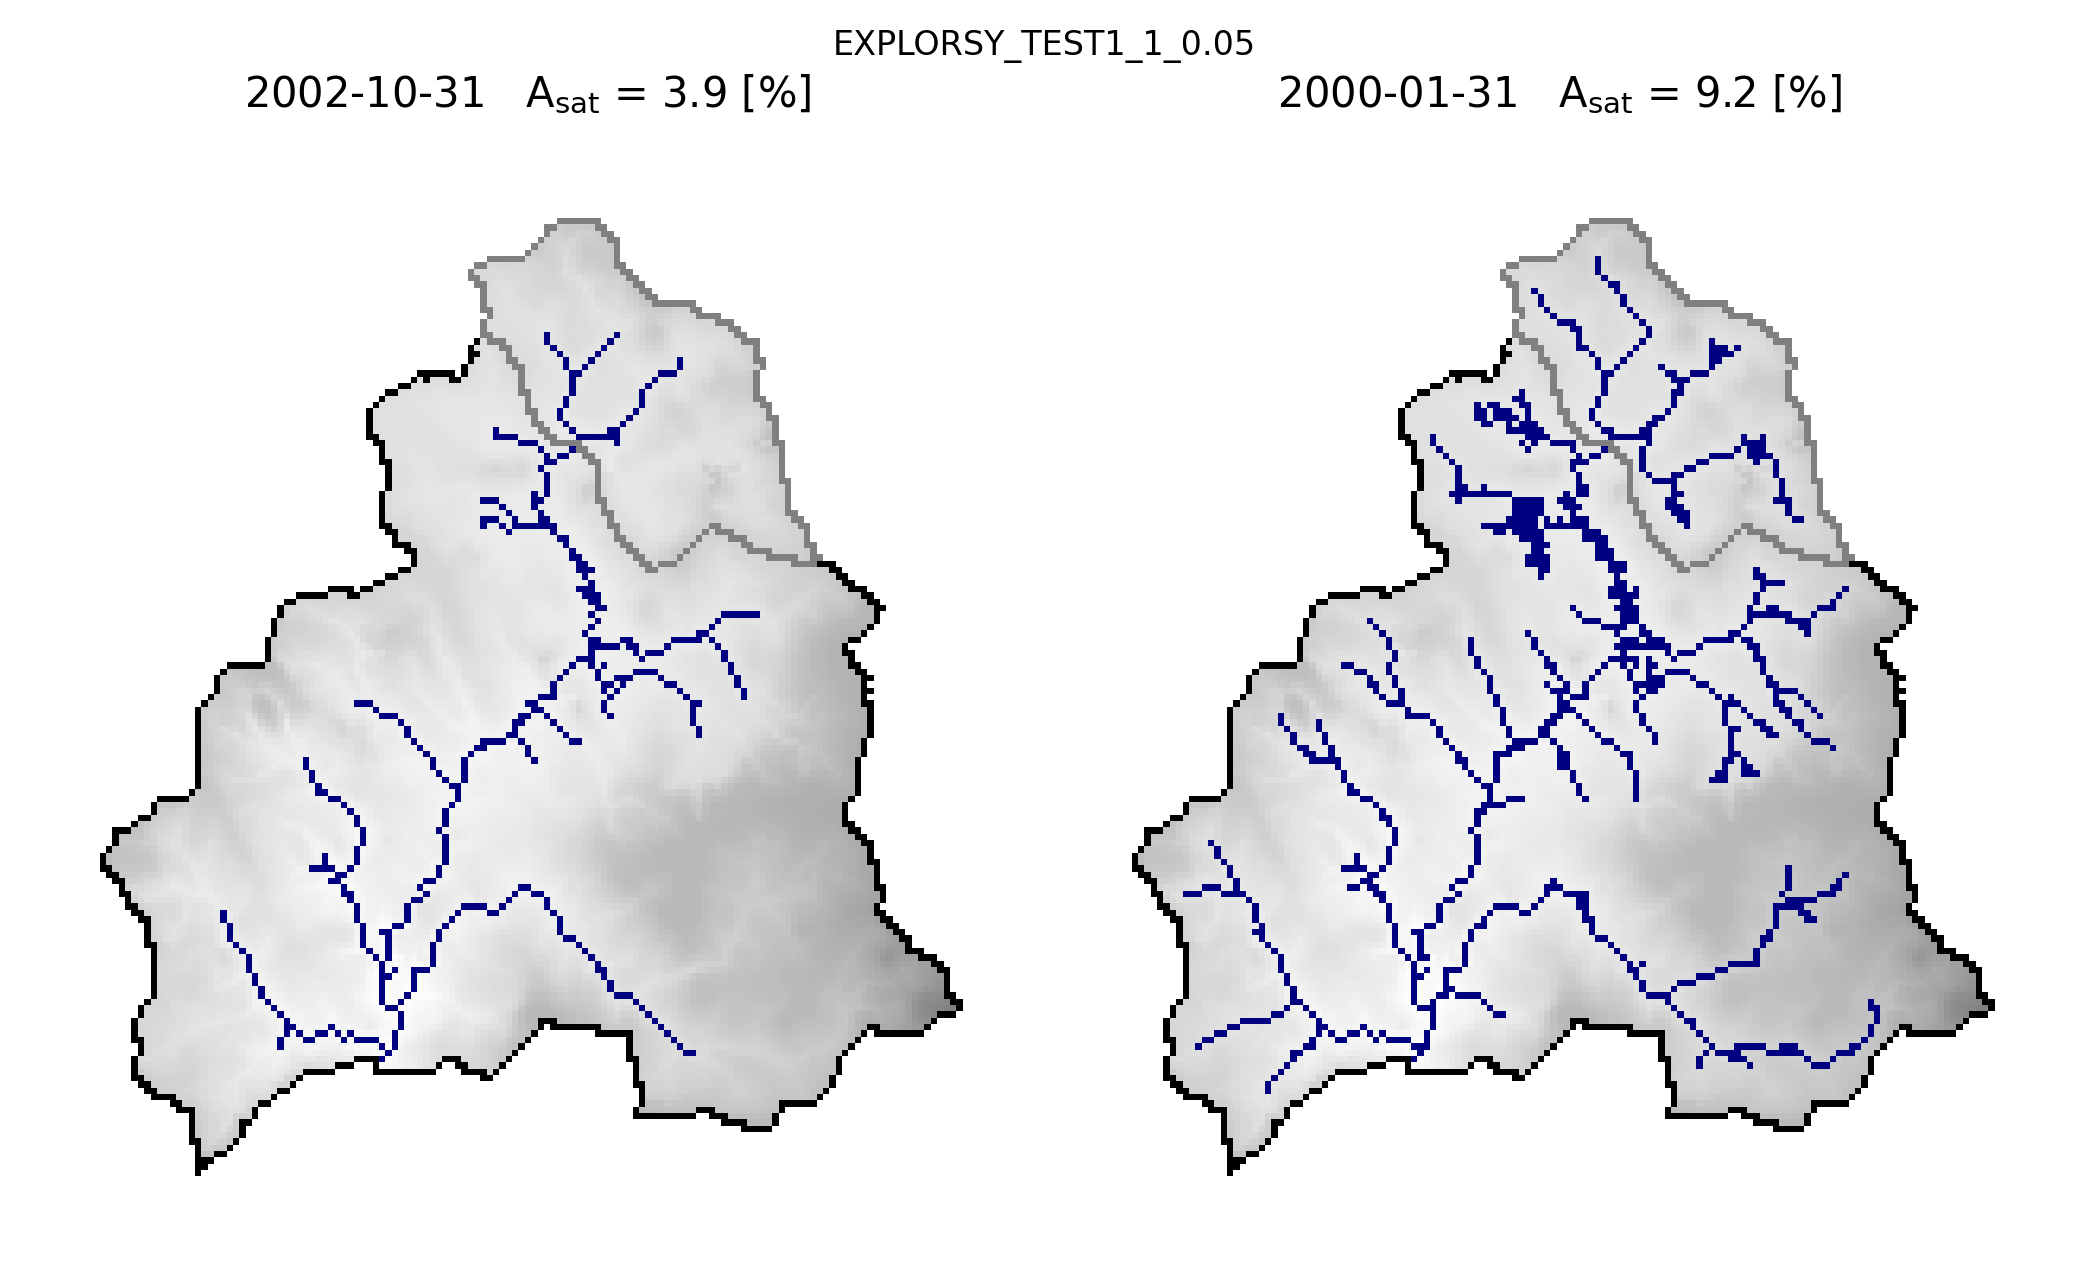

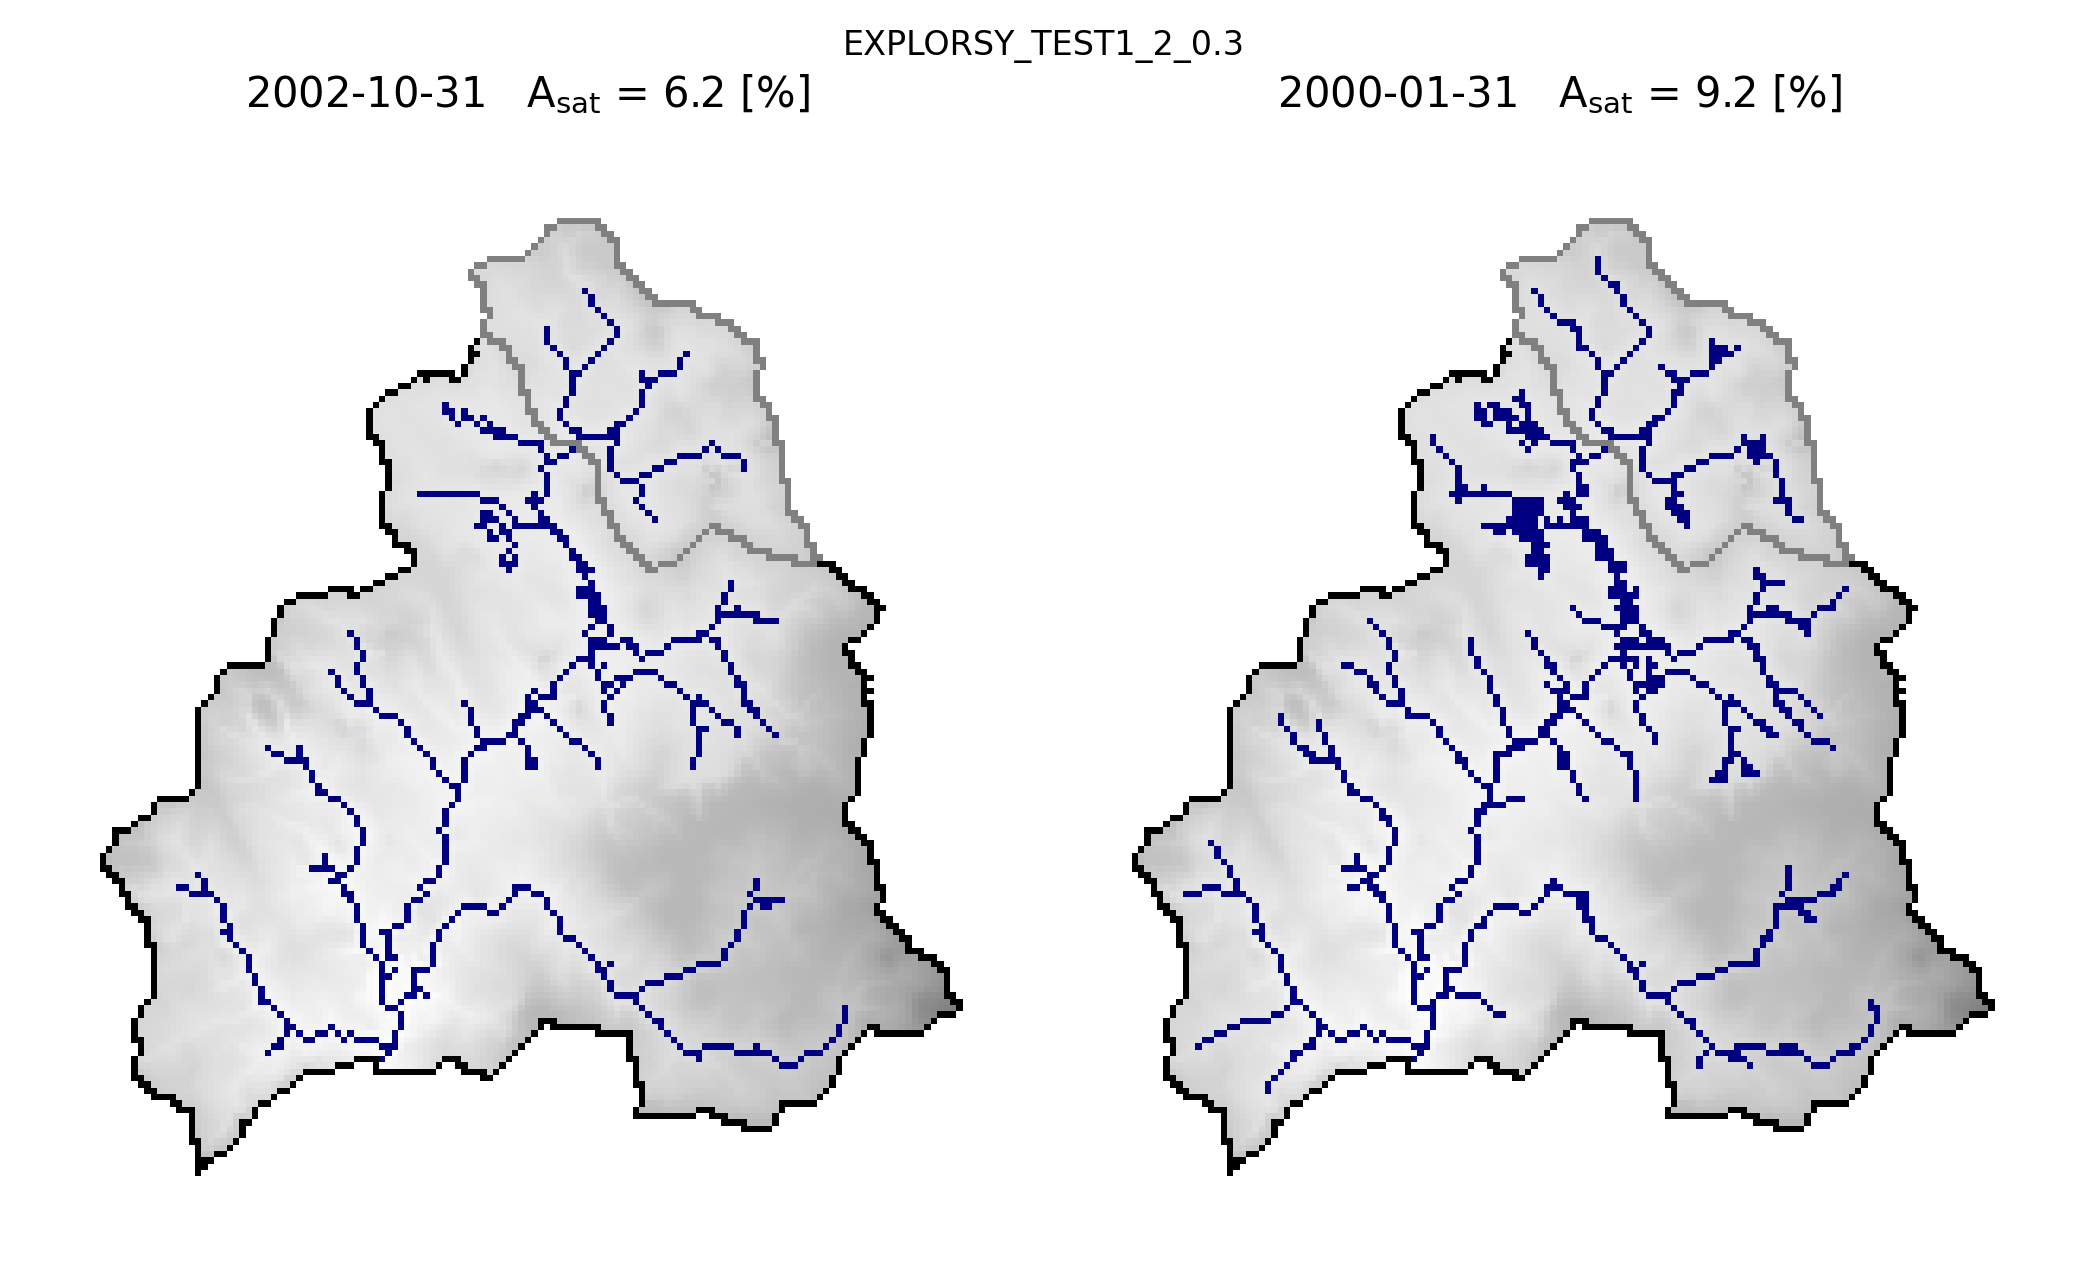

In [ ]:

dates = pd.date_range(start='01/01/2000', end='31/12/2002', freq='M')

stable_folder = os.path.join(out_path, watershed_name, 'results_stable') # necessary for plots
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')

line = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_contour.tif'))
line = np.ma.masked_where(line <= 0, line)

mask = imageio.imread(os.path.join(stable_folder, 'geographic', 'watershed_dem.tif'))

simul_list = sorted(glob.glob(os.path.join(simulations_folder, iD_set_simulations+'*')),
                   key=os.path.getmtime)

for simul in simul_list[:]:

    model_name = os.path.split(simul)[-1]

    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)

    min_area = Smod['total_areas'].min()
    min_idx = np.argmin(Smod['total_areas'])
    max_area = Smod['total_areas'].max()
    max_idx = np.argmax(Smod['total_areas'])
    max_year = Smod['total_areas'].index[max_idx]

    acc_npy = np.load(os.path.join(simul, '_postprocess', 'accumulation_flux.npy'), allow_pickle=True).item()
    inf = 0
    sup = 12
    compt = 0
    step = int(round(len(acc_npy)/12))

    for i in range(step):
        print(str(i)+'/'+str(step))
        interv = list(acc_npy.items())[inf:sup]
        for key in range(len(interv)):
            interv[key] = np.ma.masked_array(interv[key][1], mask=(mask<0))

        zero = acc_npy[0] * 0
        for j in range(len(interv)):
            tempo = interv[j].copy()
            tempo[tempo>0] = 1
            zero = zero + tempo
        days_flux = zero.copy()
        days_flux = np.ma.masked_array(days_flux, mask=(mask<0))
        days_flux = np.ma.masked_array(days_flux, mask=(days_flux<=0))

    fig, axs = plt.subplots(1,2, figsize=(7,6))
    axs = axs = axs.ravel()

    for k, j in enumerate([min_idx, max_idx]):

        ax = axs[k]

        year = Smod['total_areas'].index[j]
        val = Smod.iloc[j]['total_areas']

        days_flux = acc_npy[j]

        ax.set_title(str(year)[0:10] + '   ' + '$A_{sat}$ = ' + str(val.round(1)) + ' [%]',
                     pad=10, fontsize=10)
        ax.imshow(np.ma.masked_where(mask<0, mask), cmap='Greys', alpha=0.5, zorder=0)
        ax.imshow(np.ma.masked_where((days_flux<=0) | (mask <0),
                                     days_flux),
                  cmap = mpl.colors.ListedColormap(['navy'])) # dodgerblue
        ax.imshow(line, cmap=mpl.colors.ListedColormap('k'))

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.axis('off')

        try:
            path_sub = os.path.join(glob.glob(
                os.path.join(stable_folder, 'subbasin','intermittency*'))[0],
                'watershed_contour.shp')
            wbt.vector_lines_to_raster(path_sub,
                                       os.path.join(glob.glob(
                                           os.path.join(stable_folder,
                                                        'subbasin',
                                                        'intermittency*'))[0],
                                           'watershed_contour.tif'),
                                       base = os.path.join(stable_folder,
                                                           'geographic',
                                                           'watershed_dem.tif'))
            line_sub = imageio.imread(os.path.join(glob.glob(
                os.path.join(stable_folder, 'subbasin', 'intermittency*'))[0],
                'watershed_contour.tif'))
            line_sub = np.ma.masked_where(line_sub <= 0, line_sub)
            ax.imshow(line_sub, cmap=mpl.colors.ListedColormap('grey'))
        except:
            pass

    fig.suptitle(model_name.upper(), y=0.85, fontsize=8)

    fig.tight_layout()

    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'MAPminmax_'+model_name+'.png'),
    #             bbox_inches='tight')



<bound method Figure.tight_layout of <Figure size 2100x1800 with 6 Axes>>

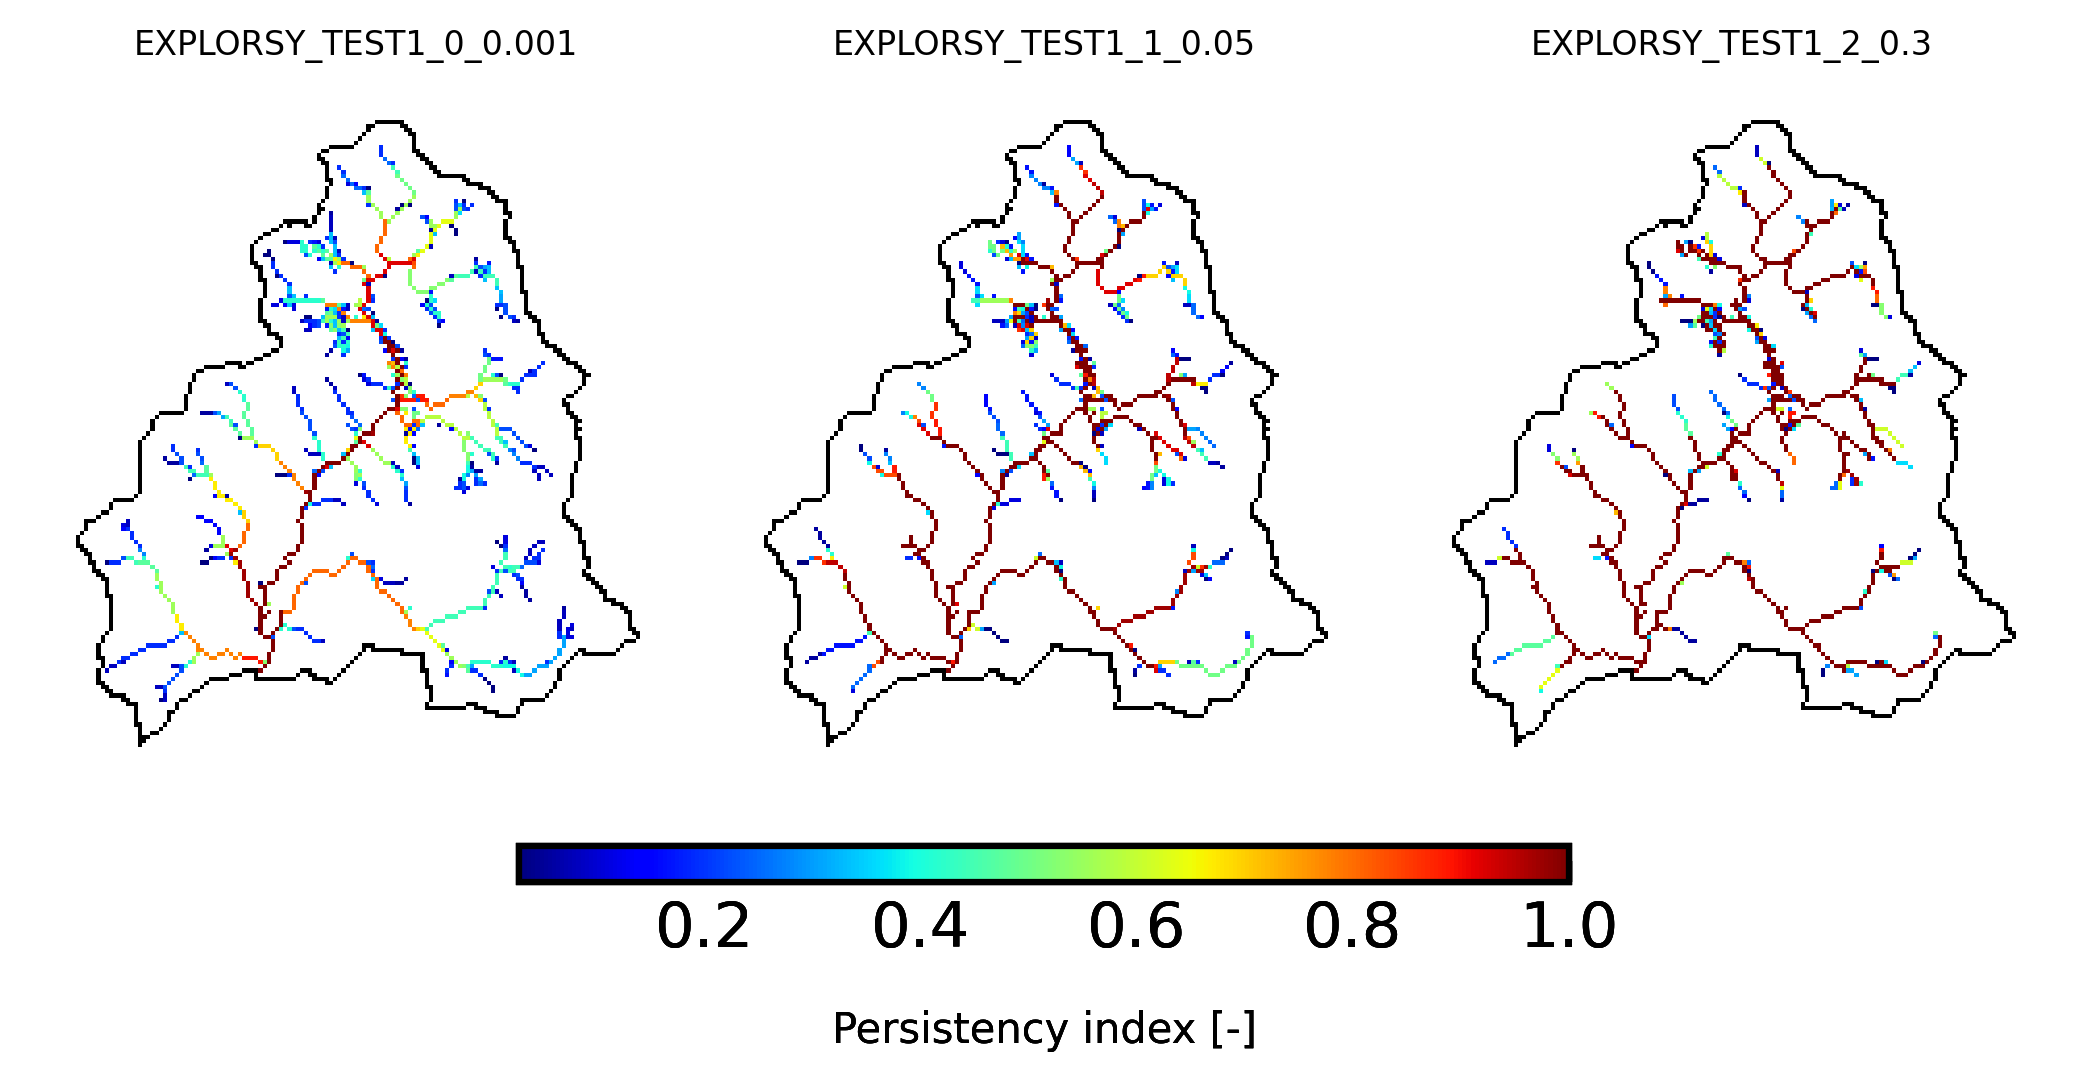

In [ ]:

simul_list = sorted(glob.glob(os.path.join(simulations_folder,
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

line = imageio.imread(os.path.join(stable_folder,
                                   'geographic',
                                   'watershed_contour.tif'))
line = np.ma.masked_where(line <= 0, line)

mask = imageio.imread(os.path.join(stable_folder,
                                   'geographic',
                                   'watershed_dem.tif'))

fig, axs = plt.subplots(1, 3, figsize=(7,6))
axs = axs = axs.ravel()

for i, simul in enumerate(simul_list[:]):

    model_name = os.path.split(simul)[-1]

    ax = axs[i]

    pi = imageio.imread(os.path.join(simul, r'_postprocess/_rasters',
                                     'persistency_index_t(-).tif'))
    pi = np.ma.masked_where(pi==-9999, pi)
    pi = np.ma.masked_where(mask==-99999, pi)

    im = ax.imshow(pi, cmap='jet')

    ax.imshow(line, mpl.colors.ListedColormap(['k']),
                  vmin=0, vmax=1)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.axis('off')

    ax.set_title(model_name.upper(), fontsize=8)

    # fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.25, 0.25, 0.5, 0.02])
    cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", pad=0.2)
    cb.set_label('Persistency index [-]', fontsize=10)  # cax == cb.ax

    fig.tight_layout()

fig.tight_layout

# fig.savefig(os.path.join(simulations_folder, '_figures',
#             'PI'+iD_set_simulations+'.png'),
#             bbox_inches='tight')



EXPLORSY_TEST1_0_0.001
0.61
-0.13
16.35
0.49
EXPLORSY_TEST1_1_0.05
0.88
0.89
9.05
0.88


EXPLORSY_TEST1_2_0.3
0.48
0.14
18.98
0.5


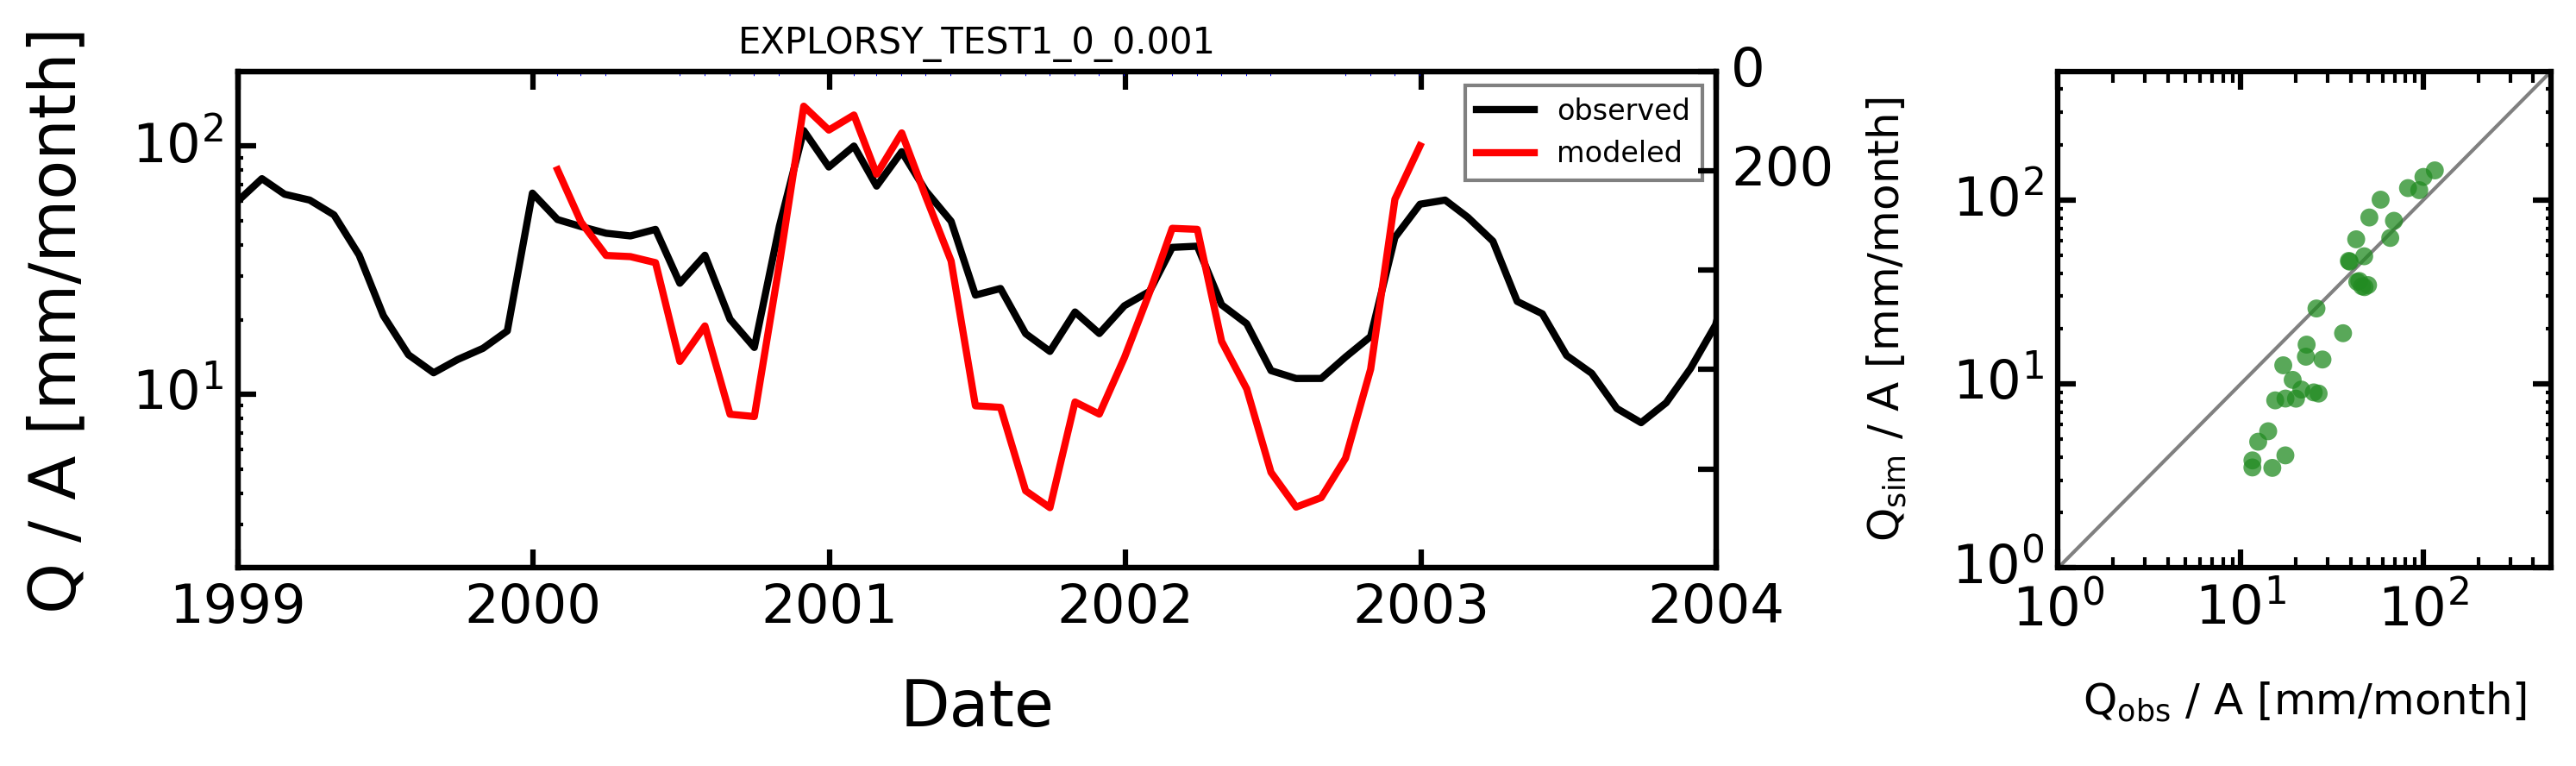

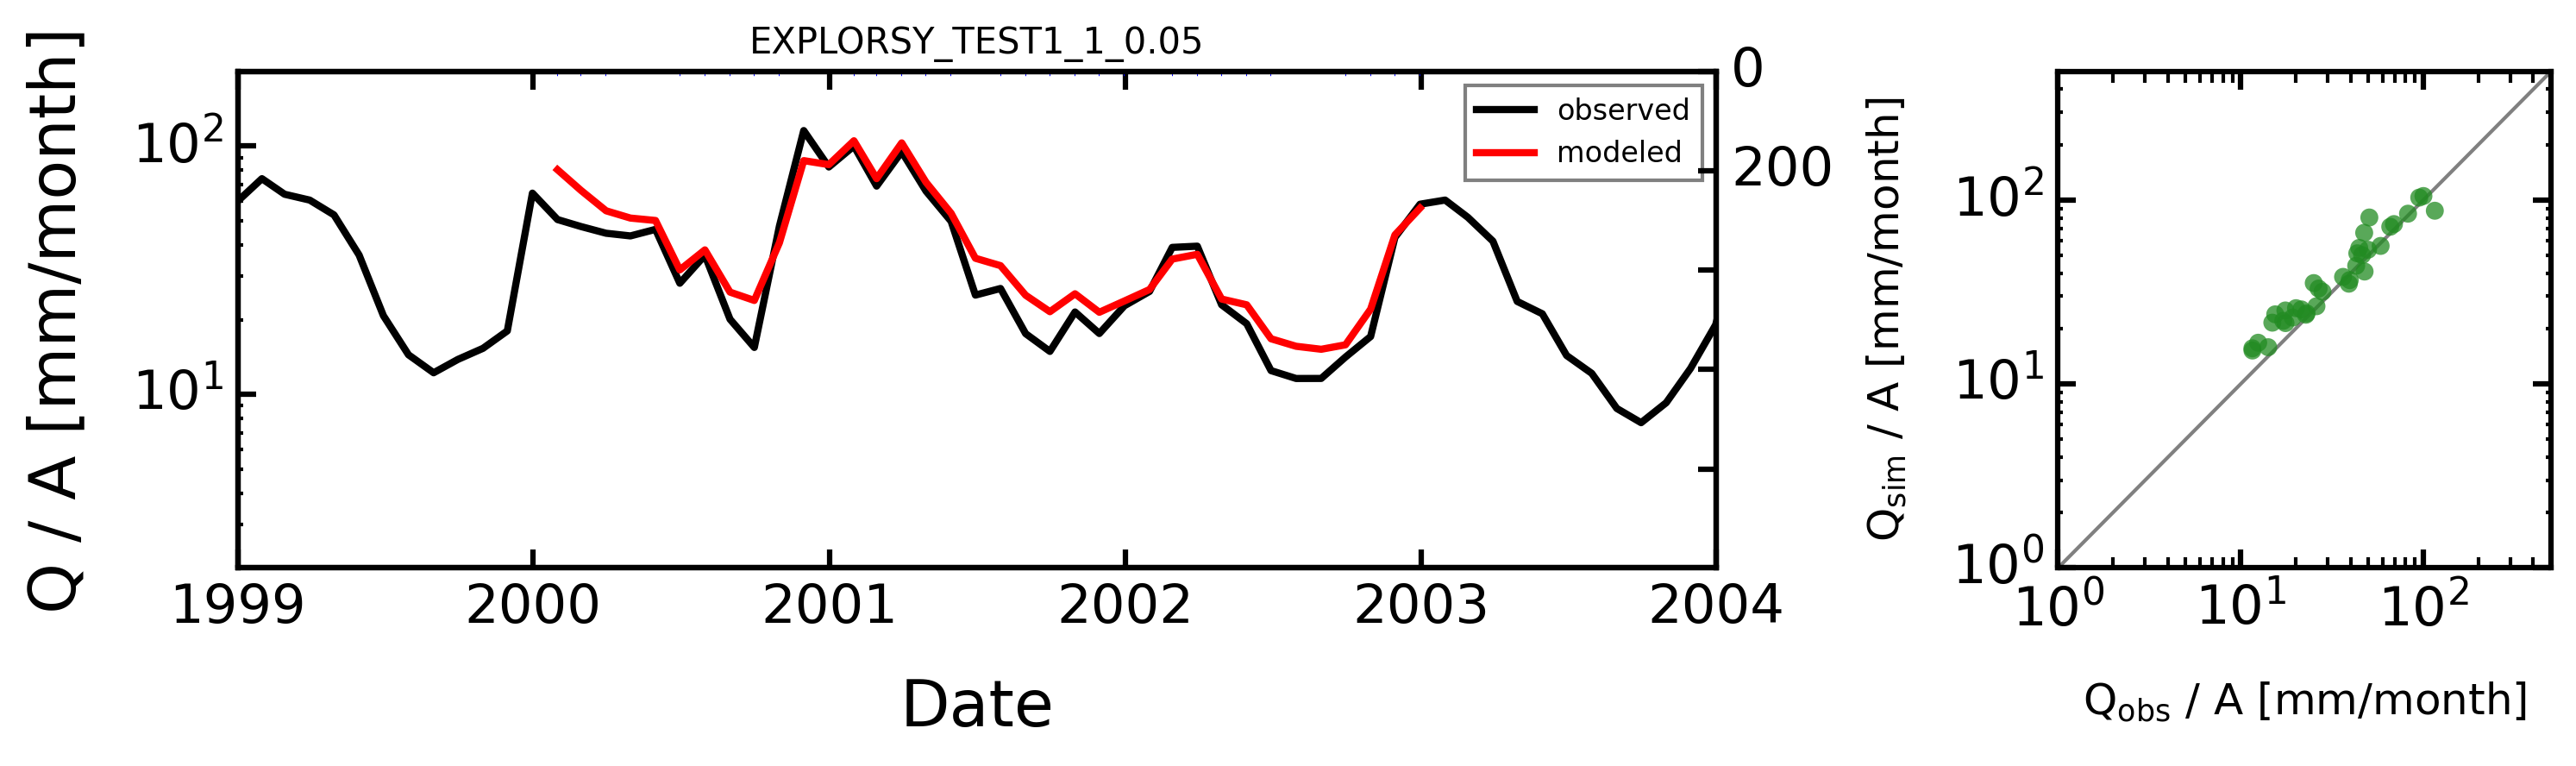

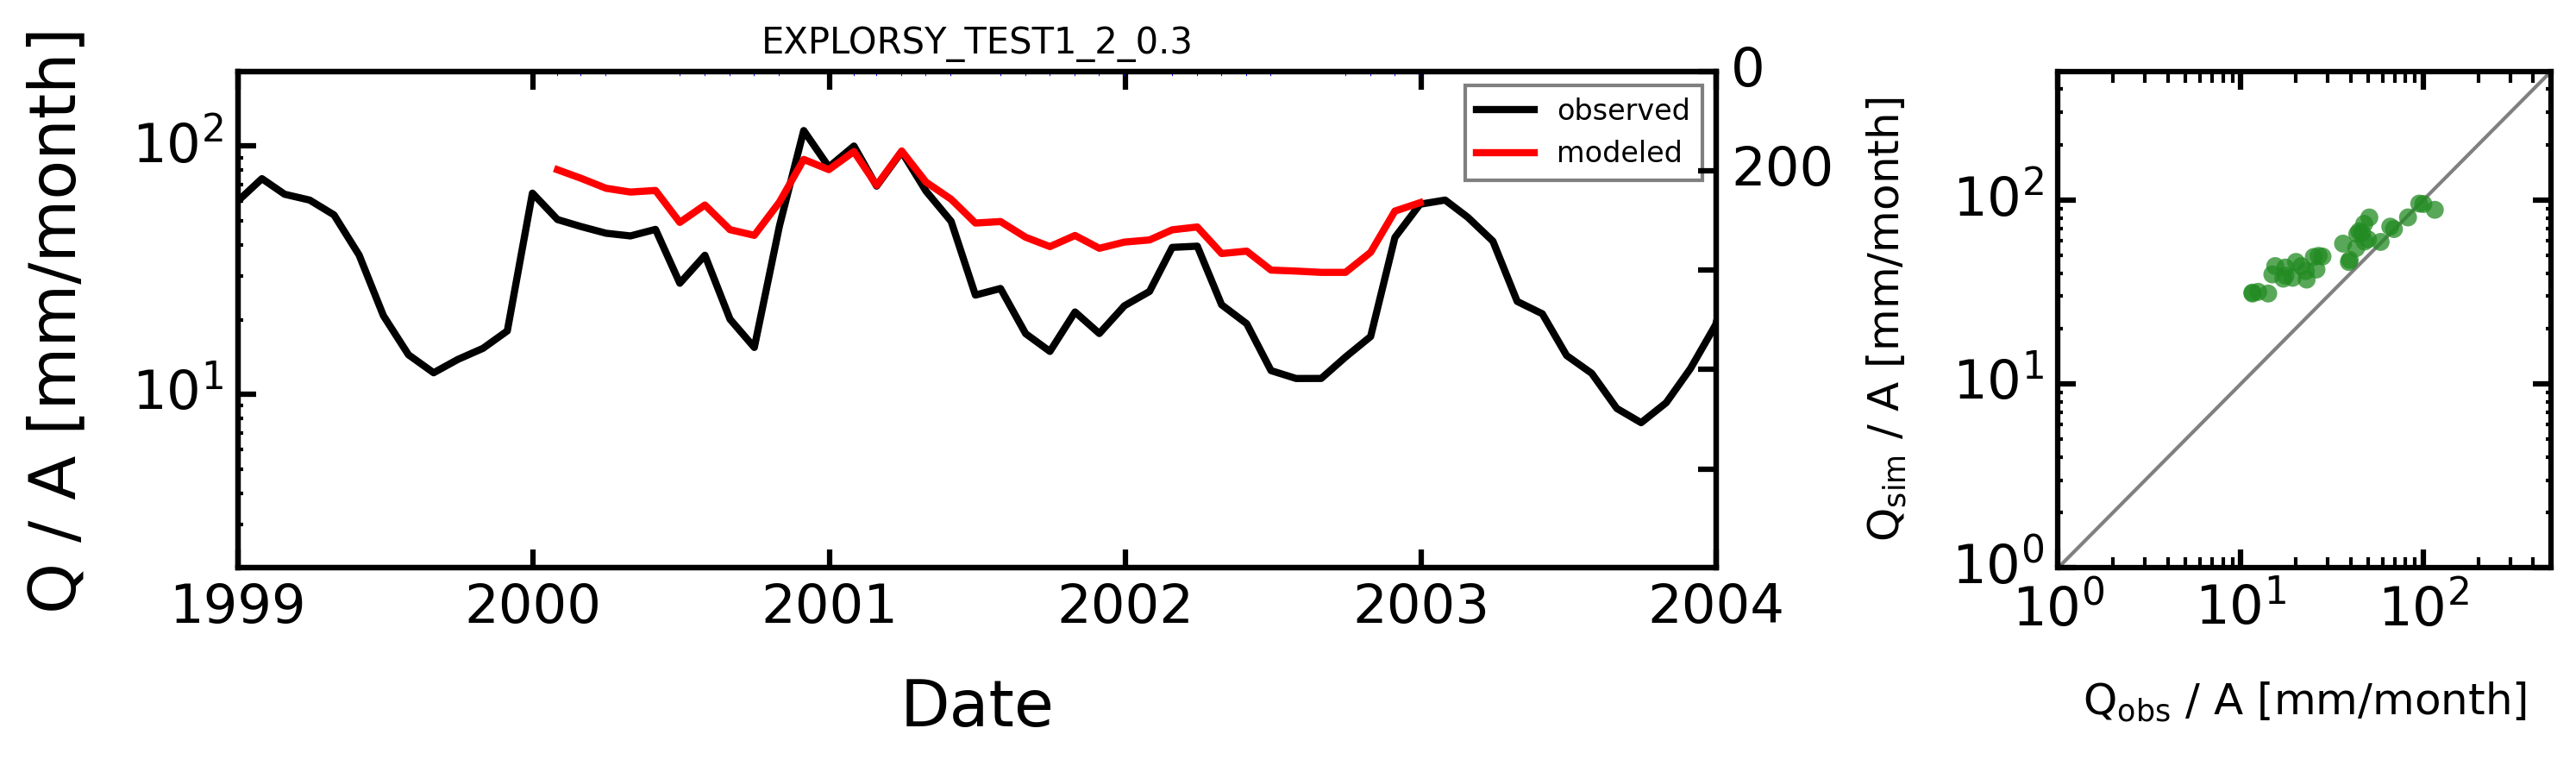

In [ ]:

# iD_set_simulations = 'explorSy_mperday_monthly_steady'
# iD_set_simulations = 'explorSy_mperday_monthly_transient'
# iD_set_simulations = 'explorSy_mpermonth_monthly_transient'
# iD_set_simulations = 'explorSy_mpermonth_monthly_steady'

Qobs_path = os.path.join(data_path, 'hydrometry catchment Nancon.csv')
Qobs = pd.read_csv(Qobs_path, sep=';', index_col=0, parse_dates=True)

area = int(round(BV.geographic.area))
Qobs = (Qobs / (area*1000000)) * (3600 * 24) # m3/s to m/day
Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month

simul_list = sorted(glob.glob(os.path.join(simulations_folder,
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):

    fig, (a0, a1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]},
                                 figsize=(10,3))

    model_name = os.path.split(simul)[-1]

    Smod_path = os.path.join(simul,
                             r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)

    Qmod = Smod['outflow_drain']
    Qmod = Qmod.squeeze() * 1000
    Qmod = (Qmod + (r * 1000)) * Qmod.index.day

    Rmod = Smod['recharge'] * Qmod.index.day

    yearsmaj = mdates.YearLocator(1)   # every year
    yearsmin = mdates.YearLocator(1)
    # monthsmaj = mdates.MonthLocator(6)  # every month
    # monthsmin = mdates.MonthLocator(3)
    # months_fmt = mdates.DateFormatter('%m') #b = name of month ?
    years_fmt = mdates.DateFormatter('%Y')

    ax = a0
    ax.plot(Qobs, color='k', lw=2, ls='-', zorder=0, label='observed')
    ax.plot(Qmod, color='red', lw=2, label='modeled')
    # ax.plot(Rmod.index, Rmod*1000, color='blue', lw=2.5)
    ax.set_xlabel('Date')
    ax.set_ylabel('Q / A [mm/month]')
    ax.set_yscale('log')
    ax.set_ylim(2,200)
    ax.xaxis.set_major_locator(yearsmaj)
    ax.xaxis.set_minor_locator(yearsmin)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.set_xlim(pd.to_datetime('1999'), pd.to_datetime('2004'))
    ax.legend()
    ax.set_title(model_name.upper(), fontsize=10)

    axb = ax.twinx()
    axb.bar(Rmod.index, Rmod,color='blue', edgecolor='blue', lw=2.5)
    axb.set_ylim(0,999)
    axb.invert_yaxis()
    axb.set_yticklabels([0,200])

    Qobs_stat = select_period(Qobs, 2000, 2002)
    Qmod_stat = select_period(Qmod, 2000, 2002)

    Qmod_stat = pd.DataFrame(Qmod_stat)
    Qmod_stat = Qmod_stat.set_index(Qobs_stat.index)

    rmse_val, nrmse, nse_val, nselog_val, bal, mare_val, kge_val = toolbox.efficiency_criteria(Qmod_stat, Qobs_stat)
    print(model_name.upper())
    print(round(nse_val,2))
    print(round(nselog_val,2))
    print(round(rmse_val,2))
    print(round(kge_val,2))

    ax = a1
    ax.scatter(Qobs_stat, Qmod_stat,
               s=25, edgecolor='none', alpha=0.75, facecolor='forestgreen')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.plot((0.1,1000),(0.1,1000), color='grey', zorder=-1)
    ax.set_xlim(1,500)
    ax.set_ylim(1,500)
    # ax.set_xlim(0.1,300)
    # ax.set_ylim(0.1,300)
    ax.set_xlabel('$Q_{obs}$ / A [mm/month]', fontsize=12)
    ax.set_ylabel('$Q_{sim}$ / A [mm/month]', fontsize=12)

    fig.tight_layout()

    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'STREAMFLOW_'+model_name+'.png'),
    #             bbox_inches='tight')



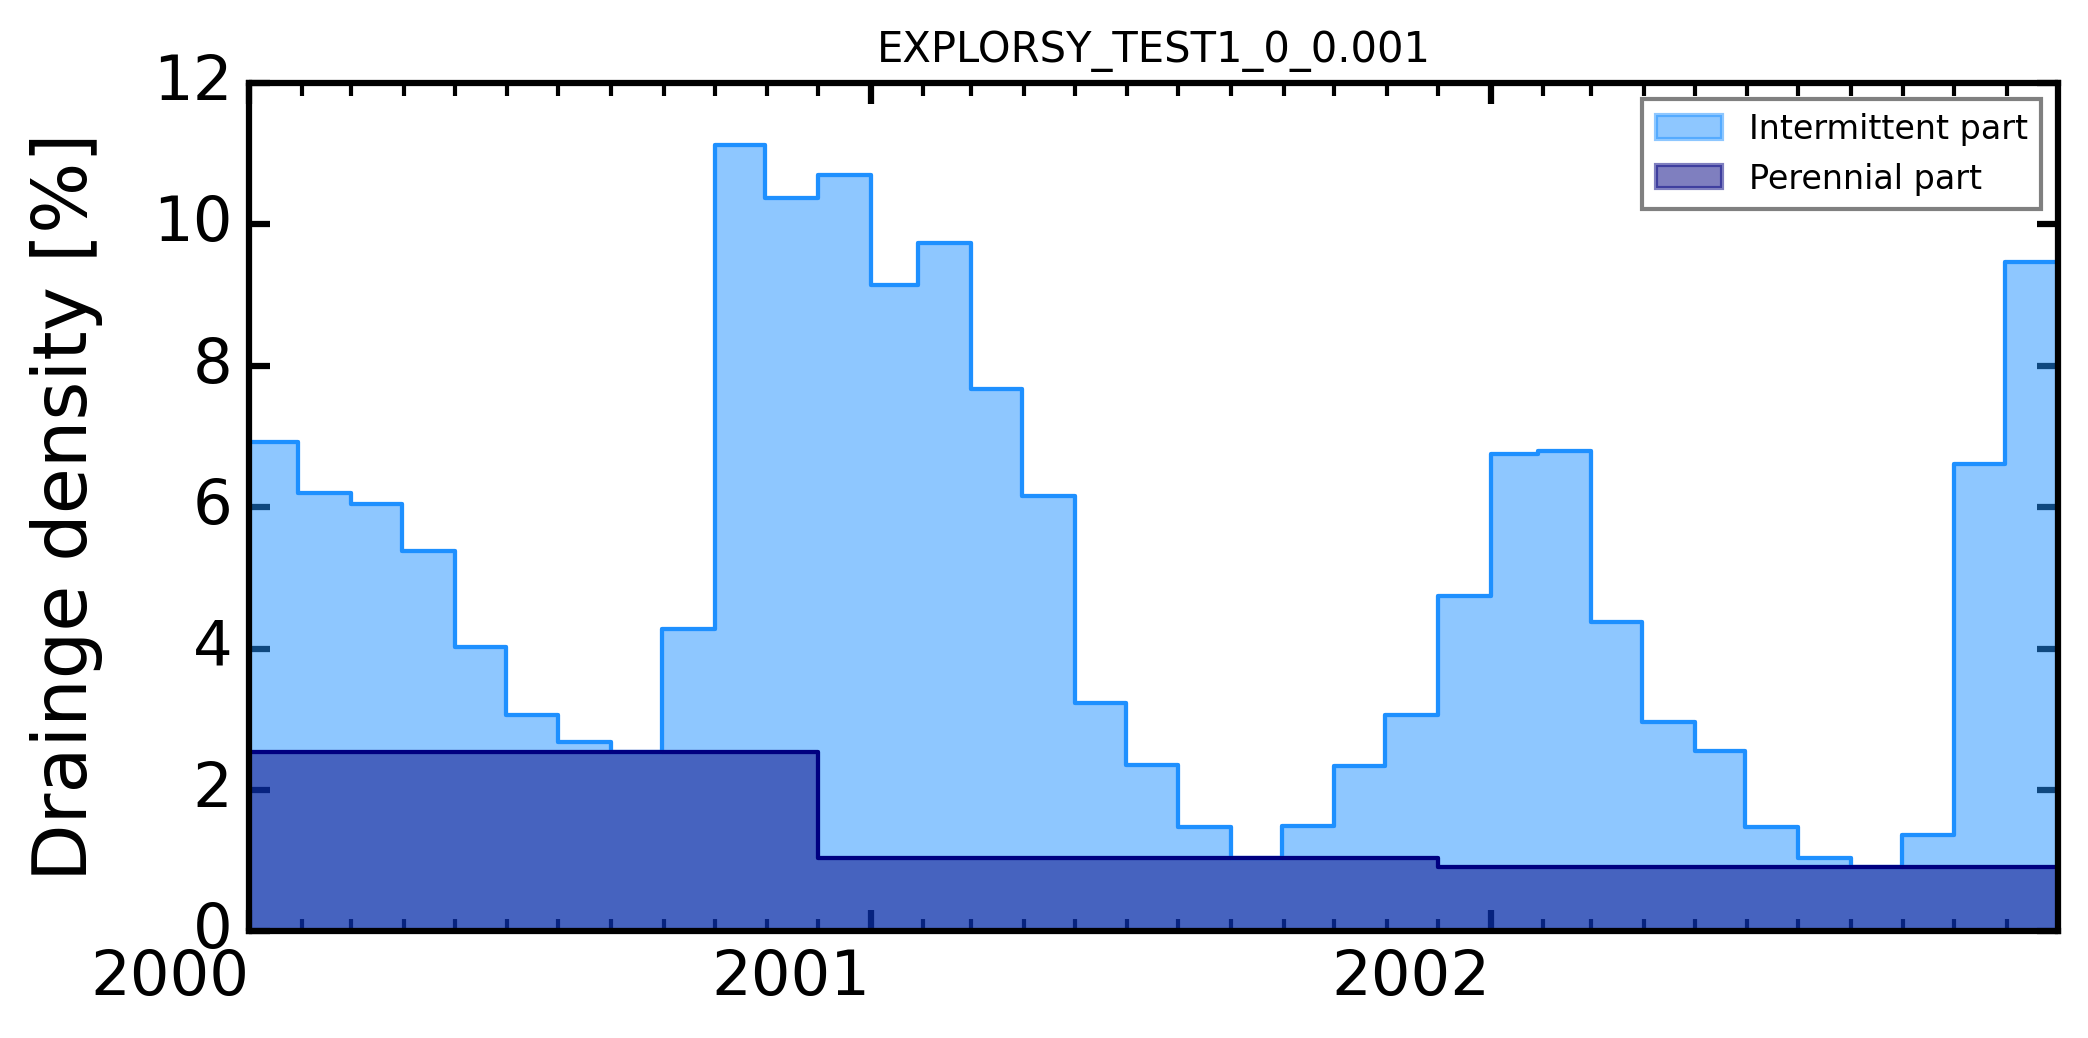

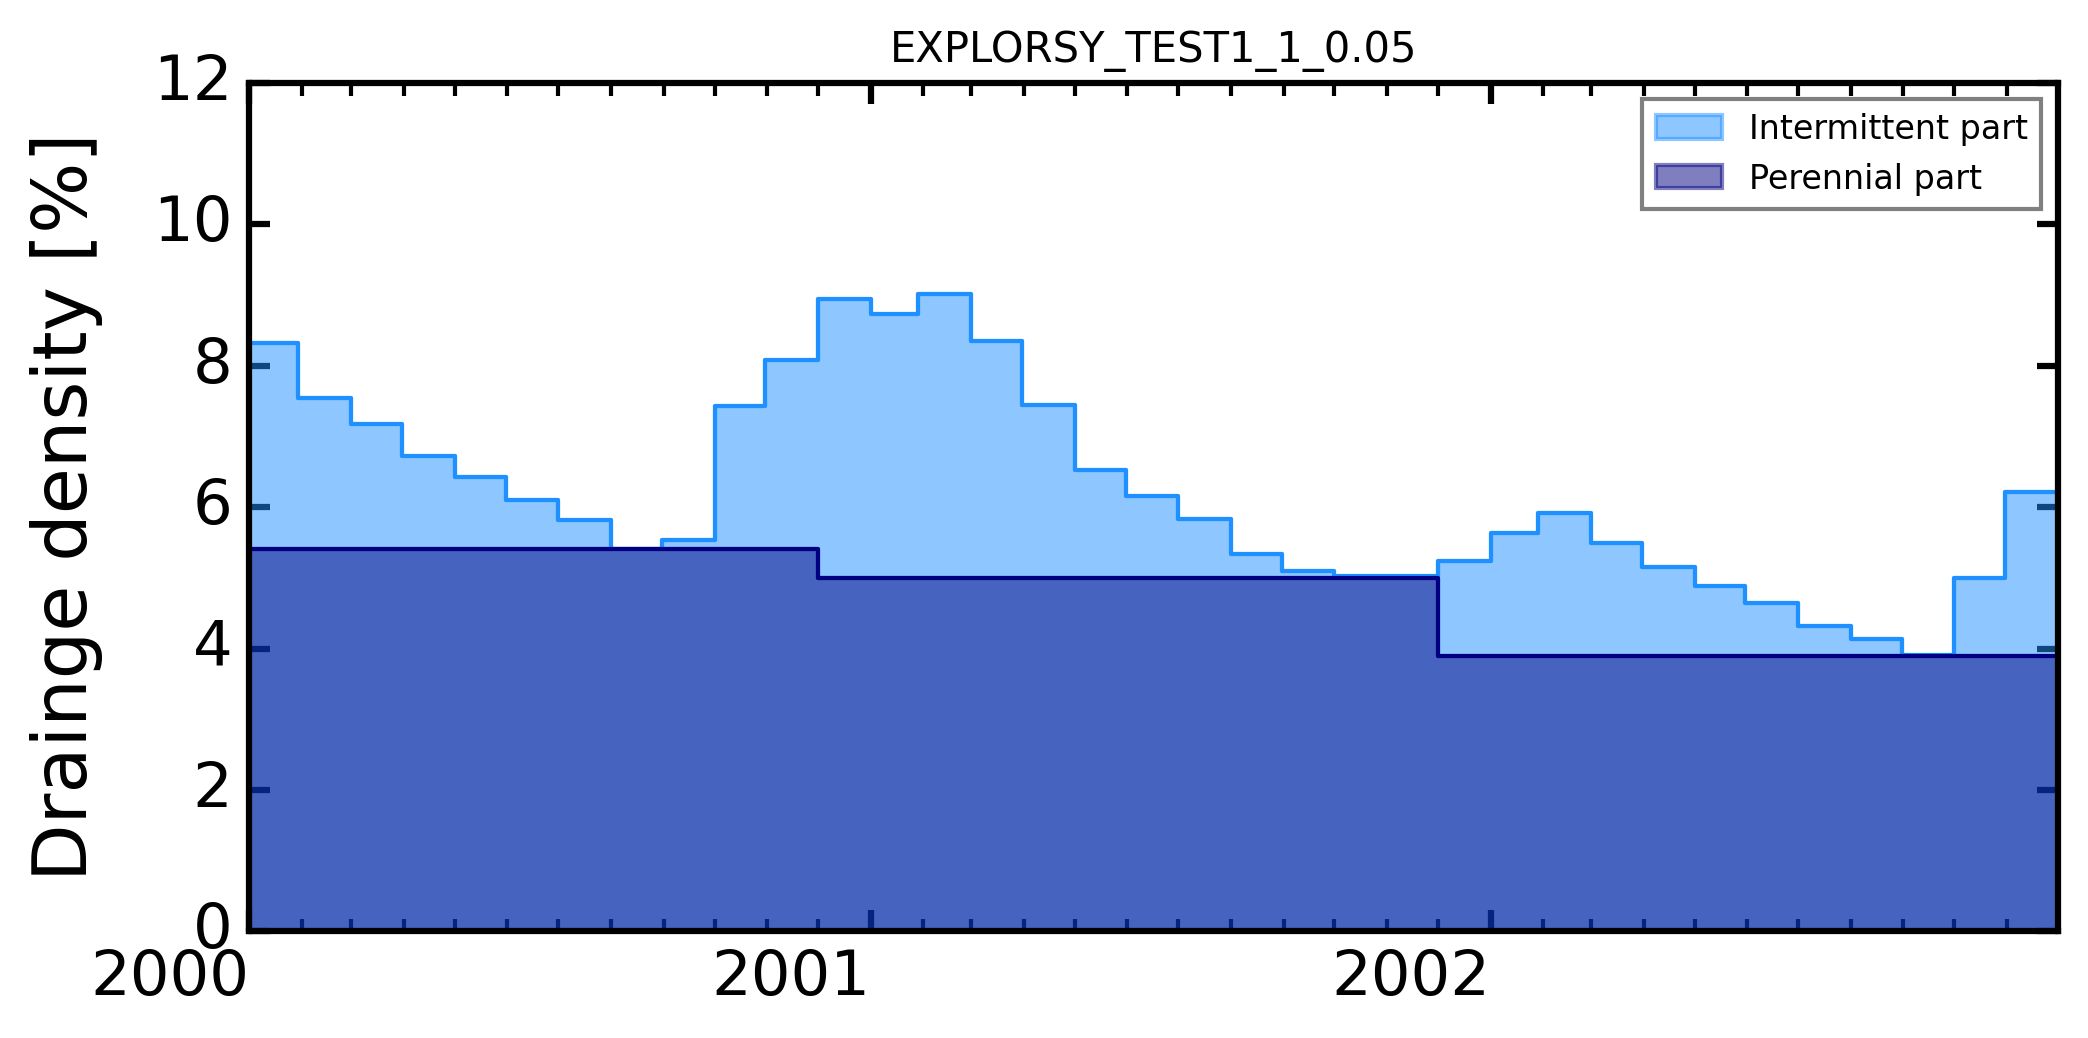

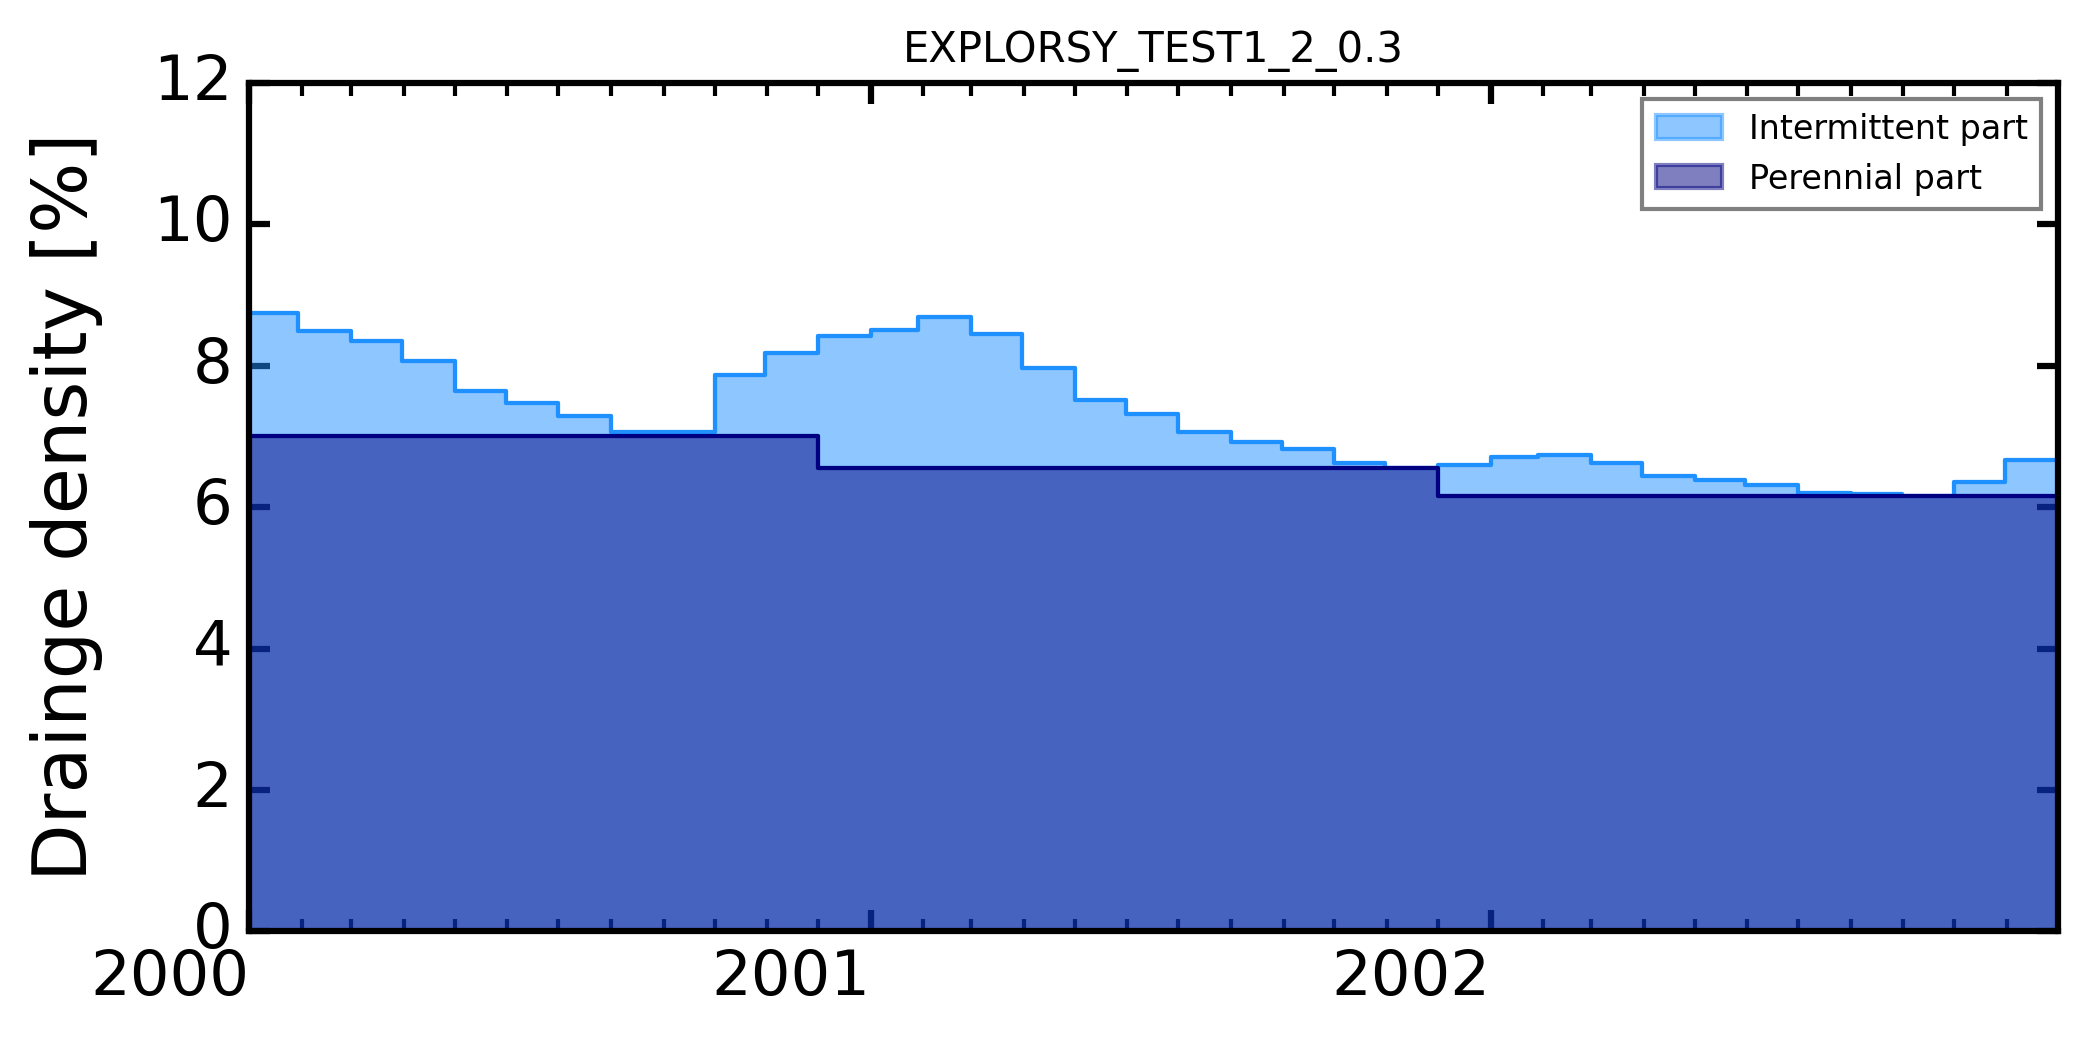

In [ ]:

def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df

Qobs_path = os.path.join(data_path, 'hydrometry catchment Nancon.csv')
Qobs = pd.read_csv(Qobs_path, sep=';', index_col=0, parse_dates=True)

area = int(round(BV.geographic.area))
Qobs = (Qobs / (area*1000000)) * (3600 * 24) # m3/s to m/day
Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month

simul_list = sorted(glob.glob(os.path.join(simulations_folder,
                                           iD_set_simulations+'*')),
                   key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):

    model_name = os.path.split(simul)[-1]

    Smod_path = os.path.join(simul,
                             r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)

    Qmod = Smod['outflow_drain']
    Qmod = Qmod.squeeze() * 1000
    Qmod = Qmod + (r * 1000)

    Rmod = Smod['recharge'] * 1000

    Sonde_path = os.path.join(glob.glob(
        os.path.join(simul, r'_subbasins/intermittency_*'))[0],
        '_simulated_timeseries.csv')
    Sonde = pd.read_csv(Sonde_path, sep=';', index_col=0, parse_dates=True)

    # BV.add_intermittency(data_path, 'regional onde stations.shp')

    # d = BV.intermittency.flowing
    # assec = d[d==1].dropna()
    # invi = d[d==2].dropna()
    # low = d[d==3].dropna()
    # accep = d[d==4].dropna()
    # visib = d[d==5].dropna()
    # d = d.resample('M').mean()

    # Smod['onde'] = d

    from datetime import timedelta
    x_months = Smod.index + timedelta(days=-30)
    Smod['date'] = x_months
    Smod.index = Smod['date']

    fig, ax = plt.subplots(1, 1, figsize=(7,3.5))

    ax.fill_between(Smod.index, 0, Smod['total_areas'],
                    interpolate=False, color='dodgerblue', alpha=0.5,
                    step='pre', label='Intermittent part')
    ax.fill_between(Smod.index, 0, Smod['perenn_areas'],
                    interpolate=False, color='navy', alpha=0.5,
                    step='pre', label='Perennial part')
    ax.legend()
    ax.step(Smod.index, Smod['total_areas'], color='dodgerblue',
            marker=None, markeredgecolor='none',
            markersize=5, lw=1, label='upstream',
            where='pre')
    ax.step(Smod.index, Smod['perenn_areas'], color='navy',
            marker=None, markeredgecolor='none',
            markersize=5, lw=1, label='upstream',
            where='pre')

    ax.set_ylim(-0,12)
    # ax.set_yticks(np.arange(0,15.05,2.5))
    ax.set_ylabel('Drainge density [%]')
    ax.set_xlim(pd.to_datetime('2000-01'), pd.to_datetime('2002-12'))
    plt.xticks(rotation=0, ha="right")

    years_maj = mdates.YearLocator()   # every year
    months_maj = mdates.MonthLocator()  # every x month
    ax.xaxis.set_major_locator(years_maj)
    ax.xaxis.set_minor_locator(months_maj)

    ax.set_title(model_name.upper(), fontsize=10)

    fig.tight_layout()

    # fig.savefig(os.path.join(simulations_folder, '_figures',
    #             'SATURATION_'+model_name+'.png'),
    #             bbox_inches='tight')



In [19]:

os.chdir(root_dir)
